# Fase 1. Análisis exploratorio y de tendencia

**Tesis** · Desigualdades socioeconómicas, étnicas y territoriales en el bajo peso al nacer
en Colombia: análisis multinivel y predictivo de las estadísticas vitales, 1998-2024
**Autor** · Gregory Jesús Meléndez · **Director** · Lihki José Rubio Ortega
**Corresponde a** · Capítulo 4, Sección 4.4.1 del manuscrito

| | |
|---|---|
| **Entra** | matriz analítica ya construida, 18.008.809 × 53 |
| **Sale** | `intermedios/muestra_analitica.parquet`, `intermedios/prevalencia_anual.parquet`, Figura 5.1, Tablas 4.1 y 5.1 |
| **Tiempo** | entre 10 y 25 minutos sobre la base completa |

---

## Qué responde esta fase

Cuántos nacimientos con bajo peso hubo en Colombia entre 1998 y 2024, cómo se distribuyen
en el tiempo y en el territorio, y cómo se relaciona esa distribución con los determinantes
sociales, **descriptivamente**.

## Qué NO responde

No estima efectos ni los aísla de la confusión. Una asociación observada aquí puede
deberse por completo a una tercera variable. Eso es trabajo de las Fases 3 a 5. Esta fase
describe; no explica.

## Cómo leer este notebook

Cada bloque son tres celdas: qué se hace y por qué, el código comentado, y cómo se lee la
salida. Las celdas de lectura están escritas **antes** de ejecutar y declaran qué se
espera, de modo que al correr el notebook la salida real se contrasta contra una
expectativa fijada de antemano y no contra una interpretación hecha a posteriori.


## 0. Preparación del entorno

**Qué hacemos.** Añadimos `src/` al camino de búsqueda de Python e importamos las
funciones compartidas del proyecto.

**Por qué `src/` y no definir todo aquí.** Tres razones. Primera, la función que carga la
base la necesitan los siete notebooks: si vive en uno, los otros seis la copian y las
copias se desincronizan. Segunda, el código de `src/` se puede versionar y revisar en
GitHub como código, no como JSON de notebook. Tercera, un notebook con doscientas líneas
de definiciones antes del primer resultado no se lee.

**Por qué se fija la semilla aquí.** `SEMILLA = 2024` es la del proyecto entero. Se pasa
explícitamente a cada función que la acepte; no confiamos en la semilla global de NumPy,
porque cualquier biblioteca importada después puede reiniciarla sin avisar y el resultado
dejaría de ser reproducible sin que nada lo indique.

In [1]:
# ---------------------------------------------------------------------------
# Entorno
# ---------------------------------------------------------------------------

import sys
from pathlib import Path

# --- Localizacion de la raiz del proyecto -----------------------------------
# NO se usa Path.cwd().parent. Motivo: VS Code ejecuta los notebooks desde la
# carpeta que tienes abierta como proyecto (jupyter.notebookFileRoot vale
# ${workspaceFolder} por defecto), NO desde notebooks/. Segun como abras la
# carpeta, cwd puede ser CODIGO_VSC o CODIGO_VSC/notebooks, y una ruta relativa
# fija falla en uno de los dos casos con ModuleNotFoundError.
#
# La solucion robusta es buscar hacia arriba la carpeta que contiene src/config.py.
def _encontrar_raiz(inicio: Path) -> Path:
    """Sube por el arbol de directorios hasta encontrar src/config.py."""
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "src" / "config.py").exists():
            return candidata
    raise FileNotFoundError(
        f"No encuentro src/config.py subiendo desde {inicio}.\n"
        "Comprueba que abriste la carpeta CODIGO_VSC en VS Code y que existe "
        "CODIGO_VSC/src/config.py."
    )

RAIZ = _encontrar_raiz(Path.cwd())
# insert(0) y no append: nuestros modulos tienen prioridad sobre cualquier
# paquete instalado que se llame igual.
sys.path.insert(0, str(RAIZ / "src"))
print(f"raiz del proyecto detectada: {RAIZ}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modulos del proyecto. Cada uno hace una cosa:
#   config     rutas, semilla y cifras de control del manuscrito
#   datos      carga, verificacion del contrato y filtro de la muestra
#   util       cronometro, guardado de tablas, versiones
#   graficos   estilo comun y guardado de figuras
#   etiquetas  significado de cada codigo, transcrito del diccionario DANE
#   asociacion chi cuadrado y V de Cramer entre variables categoricas
from config import SEMILLA, CONTROL, DIR_INTERMEDIOS
from datos import cargar_base, verificar_contrato, muestra_analitica, guardar_intermedio
from util import cronometro, guardar_tabla, versiones
from graficos import estilo, guardar_figura, etiquetar_fin_de_linea
import etiquetas
import asociacion

# Aplica el estilo de figuras del proyecto. Llamarlo una vez basta para todo el
# notebook: matplotlib guarda los parametros de forma global.
estilo()

# Que pandas no recorte las columnas al imprimir. Con 53 columnas, el
# comportamiento por defecto oculta justo las que interesa mirar.
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

print(f"Raiz del proyecto: {RAIZ}")
print(f"Semilla: {SEMILLA}")

# --- Sello de version del notebook -----------------------------------------
#
# POR QUE ESTO ESTA AQUI: VS Code conserva el estado no guardado de cada
# editor y lo restaura al recargar la ventana. Un notebook regenerado en disco
# puede seguir ejecutandose en su version anterior sin que nada lo delate: el
# archivo es nuevo, la pestana es vieja, y las salidas corresponden a un codigo
# que ya no existe. Eso ya provoco que se interpretaran resultados obsoletos.
#
# VERSION es la huella del contenido de este notebook en el momento de
# generarlo. La celda la compara contra la del archivo en disco. Si difieren,
# la pestana esta desactualizada y hay que revertirla:
#     Ctrl+Shift+P -> File: Revert File
VERSION = "84fa0e08"
print(f"\nversion del notebook en memoria: {VERSION}")

try:
    import hashlib, json as _json
    _ruta_nb = RAIZ / "notebooks" / "01_eda.ipynb"
    _celdas = _json.load(open(_ruta_nb, encoding="utf-8"))["cells"]
    _texto = "\n".join("".join(c["source"]) for c in _celdas)
    # Se retira el propio sello antes de calcular, igual que al generarlo.
    _texto = _texto.replace(VERSION, "")
    _disco = hashlib.sha1(_texto.encode("utf-8")).hexdigest()[:8]
    print(f"version del archivo en disco   : {_disco}")
    if _disco == VERSION:
        print("COINCIDEN: estas ejecutando la version actual.")
    else:
        print("\n" + "!" * 64)
        print("NO COINCIDEN. La pestana abierta es una version anterior.")
        print("Ctrl+Shift+P -> 'File: Revert File', y vuelve a correr.")
        print("No interpretes las salidas de esta corrida.")
        print("!" * 64)
except FileNotFoundError:
    print("(no se encontro el archivo en disco para comparar)")

raiz del proyecto detectada: c:\Users\ASUS\Desktop\TESIS\CODIGO_VSC
Raiz del proyecto: c:\Users\ASUS\Desktop\TESIS\CODIGO_VSC
Semilla: 2024

version del notebook en memoria: 84fa0e08
version del archivo en disco   : 84fa0e08
COINCIDEN: estas ejecutando la version actual.


**Cómo se lee esta salida.** Solo confirma que el notebook encontró `src/`. Si sale
`ModuleNotFoundError: config`, el notebook no está dentro de `notebooks/` o falta correr
`generar_proyecto.py`.

## 1. Carga y verificación del contrato de datos

**Qué hacemos.** Cargamos la matriz analítica y comprobamos que es exactamente la que
describe el manuscrito: 18.008.809 filas, 53 columnas, años 1998 a 2024.

**Por qué verificamos en lugar de confiar.** Todas las cifras de los Capítulos 4 y 5 se
calcularon sobre una versión concreta de la matriz. Si alguien la reconstruyera cambiando
una regla de exclusión, los números del documento dejarían de corresponder al código **sin
que nada fallara**. No habría error, habría una tesis incoherente. Verificar al arrancar
convierte ese fallo silencioso en un fallo ruidoso.

**Por qué la matriz no se reconstruye aquí.** Ya se construyó, con su propio script
auditado y su crosswalk versionado. Reconstruirla en cada análisis sería lento y, sobre
todo, arriesgaría producir una versión distinta cada vez.

In [2]:
# ---------------------------------------------------------------------------
# Carga de la matriz analitica
# ---------------------------------------------------------------------------

# cargar_base() anade la carpeta DATA al path e invoca cargar_matriz.cargar().
# El cronometro esta porque son 1,25 GB: sin el, una espera de dos minutos se
# confunde con un kernel colgado.
with cronometro("carga de la base"):
    df = cargar_base()

# verificar_contrato compara contra las cifras de config.CONTROL y lanza
# excepcion si algo no cuadra. estricto=False devuelve la lista de problemas en
# vez de detener, util cuando se esta depurando.
problemas = verificar_contrato(df, estricto=False)

if problemas:
    print("\n*** LA BASE NO COINCIDE CON EL CONTRATO ***")
    for p in problemas:
        print("  -", p)
    print("Resuelve esto ANTES de calcular nada.")
else:
    print("\nContrato verificado: la base es la que describe el manuscrito.")

print(f"\nDimensiones : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Periodo     : {int(df['ANIO'].min())}-{int(df['ANIO'].max())} "
      f"({df['ANIO'].nunique()} anios)")
# deep=True recorre los objetos; sin el, pandas subestima la memoria de las
# columnas de texto porque solo cuenta los punteros.
print(f"Memoria     : {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

[inicio] carga de la base
capa 'analitica' | 18,008,809 filas x 53 columnas
años: 1998-2024 (27)
memoria: 1.25 GB
[fin]    carga de la base  ->  1.9 min

Contrato verificado: la base es la que describe el manuscrito.

Dimensiones : 18,008,809 filas x 53 columnas
Periodo     : 1998-2024 (27 anios)
Memoria     : 1.16 GB


**Cómo se lee esta salida.**

Debe decir exactamente `18,008,809 filas x 53 columnas`, `1998-2024 (27 años)` y
alrededor de `1.25 GB`.

- **Si las filas no coinciden**, la matriz se reconstruyó. Para aquí. Todas las cifras del
  manuscrito quedan en cuestión hasta saber qué cambió.
- **Si faltan columnas**, la capa cargada no es `analitica`. Revisa `cargar_matriz.py`.
- **Si la memoria es muy superior a 1,25 GB**, las columnas categóricas se están cargando
  como texto y todo lo que sigue va a ir mucho más lento de lo necesario.

## 2. Inventario de las 53 columnas

**Qué hacemos.** Una tabla con cada columna, su tipo, cuántos niveles distintos toma y qué
porcentaje de registros la tiene informada.

**Por qué antes que nada.** Es la fotografía que decide qué se puede analizar. Una variable
con 12 % de completitud no sostiene un modelo, por interesante que sea conceptualmente. Y
una variable que dice ser categórica pero tiene 40.000 niveles distintos es en realidad un
campo de texto libre mal tipificado.

**Qué buscamos.** Tres cosas concretas: variables con completitud baja, variables con un
solo nivel (no aportan nada y algunos modelos fallan con ellas), y categóricas con
cardinalidad sospechosamente alta.

**Esta tabla va al Apéndice B del manuscrito.**

In [3]:
# ---------------------------------------------------------------------------
# Inventario de columnas
# ---------------------------------------------------------------------------

# --- Clasificacion funcional de las 53 columnas ----------------------------
#
# POR QUE AGRUPAR Y NO ORDENAR SOLO POR COMPLETITUD: ordenada por completitud,
# la tabla mezcla el nombre del hospital con el nivel educativo de la madre, y
# no se puede leer. Lo que decide si una columna entra al analisis no es cuan
# completa esta, sino QUE ES. Agrupada por funcion, la tabla responde de un
# vistazo a la pregunta que importa: cuantas variables hay de cada tipo y cual
# es su estado.
#
# El orden de los grupos va del descarte seguro a las variables del estudio.
GRUPOS = {
    "1 metadato": [
        "ARCHIVO_ORIGEN", "CATALOGO_DANE", "ESQUEMA_CODIGOS", "N_VARS_ORIGEN",
        "FILA_CORRIDA", "ES_DUPLICADO_EXACTO", "NOM_INST", "COD_INST",
        "ANO", "MES", "FECHA_NACM", "TIPOFORMULARIO", "OTRPARATX",
        "NOMCLASAD", "IDCLASADMI"],
    "2 fuga": [
        "PESO_NAC", "TALLA_NAC", "APGAR1", "APGAR2", "GRU_SAN",
        "IDHEMOCLAS", "IDFACTORRH", "ATEN_PAR", "OTRO_SIT", "T_GES_AGRU_CIE"],
    "3 desenlace": ["BPN"],
    "4 estructura": ["ANIO", "CODPTORE", "CODMUNRE", "COD_DPTO", "COD_MUNIC"],
    "5 social": [
        "NIV_EDUM", "NIV_EDUP", "SEG_SOCIAL", "EST_CIVM", "AREA_RES",
        "IDPERTET", "PROFESION", "ULTCURMAD", "ULTCURPAD", "CODPRES",
        "CODPAISNACMAD"],
    "6 obstetrica": [
        "EDAD_MADRE", "EDAD_PADRE", "NUMCONSUL", "N_EMB", "N_HIJOSV",
        "T_GES", "MUL_PARTO", "TIPO_PARTO", "SIT_PARTO", "SEXO", "AREANAC"],
}

# Diccionario inverso columna -> grupo, y motivo del descarte cuando aplica.
GRUPO_DE = {c: g for g, cols in GRUPOS.items() for c in cols}
MOTIVO = {
    "1 metadato":   "trazabilidad del procesamiento, no es variable del estudio",
    "2 fuga":       "se conoce durante o despues del parto",
    "3 desenlace":  "variable respuesta",
    "4 estructura": "niveles del modelo multinivel",
    "5 social":     "determinante social, objeto de la tesis",
    "6 obstetrica": "mediador potencial de la posicion social",
}

filas = []
for col in df.columns:
    s = df[col]
    grupo = GRUPO_DE.get(col, "7 sin clasificar")
    filas.append({
        "grupo": grupo,
        "variable": col,
        "funcion": MOTIVO.get(grupo, "revisar: no clasificada"),
        "tipo": str(s.dtype),
        # nunique con dropna=True: los nulos no son un nivel de la variable.
        "niveles": s.nunique(dropna=True),
        # notna().mean() da la proporcion de informados. Sobre la columna y no
        # con count()/len() porque es mas rapido y no crea copias.
        "completitud_pct": round(s.notna().mean() * 100, 2),
        "nulos": int(s.isna().sum()),
    })

inventario = pd.DataFrame(filas)

# Orden: primero por grupo (el prefijo numerico lo garantiza), y DENTRO de cada
# grupo por completitud descendente. Asi los bloques quedan juntos y, dentro de
# cada bloque, arriba lo que esta en mejor estado.
inventario = (inventario
              .sort_values(["grupo", "completitud_pct"],
                           ascending=[True, False])
              .reset_index(drop=True))

# Guardamos ya, en .csv y en .tex. El .tex se inserta en el manuscrito con
# \input{}, de modo que si el analisis cambia la tabla del documento cambia
# sola. Copiar numeros a mano es de donde salen las incoherencias.
guardar_tabla(inventario, "inventario_columnas", decimales=2)

# --- Resumen por grupo -----------------------------------------------------
resumen = (inventario.groupby("grupo")
           .agg(columnas=("variable", "size"),
                completitud_mediana=("completitud_pct", "median"),
                completitud_min=("completitud_pct", "min"))
           .round(1))
print("COLUMNAS POR FUNCION")
print(resumen.to_string())

n_cand = int(inventario["grupo"].isin(["5 social", "6 obstetrica"]).sum())
print(f"\ncandidatas al modelo (social + obstetrica): {n_cand} de {len(inventario)}")

sin_clasificar = inventario.loc[inventario["grupo"] == "7 sin clasificar",
                                "variable"].tolist()
if sin_clasificar:
    print(f"\nSIN CLASIFICAR, hay que decidir que son: {sin_clasificar}")

print(f"\ncompletitud < 50 %        : {(inventario['completitud_pct'] < 50).sum()}")
print(f"un solo nivel             : {(inventario['niveles'] <= 1).sum()}")
print(f"mas de 1.000 niveles      : {(inventario['niveles'] > 1000).sum()}")

inventario

tabla guardada: inventario_columnas.csv y inventario_columnas.tex
COLUMNAS POR FUNCION
              columnas  completitud_mediana  completitud_min
grupo                                                       
1 metadato          15                100.0              0.0
2 fuga              10                 76.7              0.1
3 desenlace          1                 98.2             98.2
4 estructura         5                100.0             99.6
5 social            11                 96.1              2.5
6 obstetrica        11                 98.8             92.3

candidatas al modelo (social + obstetrica): 22 de 53

completitud < 50 %        : 9
un solo nivel             : 0
mas de 1.000 niveles      : 4


,grupo,variable,funcion,tipo,niveles,completitud_pct,nulos
0,1 metadato,ARCHIVO_ORIGEN,"trazabilidad del procesamiento, no es variable...",category,27,100.00,0
1,1 metadato,CATALOGO_DANE,"trazabilidad del procesamiento, no es variable...",category,13,100.00,0
2,1 metadato,ESQUEMA_CODIGOS,"trazabilidad del procesamiento, no es variable...",category,6,100.00,0
3,1 metadato,N_VARS_ORIGEN,"trazabilidad del procesamiento, no es variable...",category,6,100.00,0
4,1 metadato,ANO,"trazabilidad del procesamiento, no es variable...",category,39,100.00,0
5,1 metadato,MES,"trazabilidad del procesamiento, no es variable...",category,22,100.00,0
6,1 metadato,FILA_CORRIDA,"trazabilidad del procesamiento, no es variable...",bool,2,100.00,0
7,1 metadato,ES_DUPLICADO_EXACTO,"trazabilidad del procesamiento, no es variable...",bool,2,100.00,0
8,1 metadato,FECHA_NACM,"trazabilidad del procesamiento, no es variable...",category,20997,63.71,6534886
9,1 metadato,IDCLASADMI,"trazabilidad del procesamiento, no es variable...",category,5,55.26,8057472


**Cómo se lee esta salida.**

**La tabla va agrupada por función, no por completitud.** Es lo que permite leerla: ordenada
solo por completitud, el nombre del hospital aparece junto al nivel educativo de la madre y
no se distingue nada. Dentro de cada grupo sí manda la completitud.

Los siete grupos, en el orden en que salen:

| Grupo | Qué es | Qué se hace con él |
|---|---|---|
| **1 metadato** | trazabilidad del procesamiento | fuera: no son variables del estudio |
| **2 fuga** | se conoce durante o después del parto | **fuera, obligatorio**: un modelo prenatal no puede usarlas |
| **3 desenlace** | `BPN` | la variable respuesta |
| **4 estructura** | códigos territoriales y año | niveles del modelo multinivel, no predictores |
| **5 social** | los determinantes | el objeto de la tesis |
| **6 obstétrica** | mediadores potenciales | entran, pero con la distinción confusor/mediador |
| **7 sin clasificar** | lo que no encajó | **hay que decidir qué es antes de seguir** |

**Qué mirar, en este orden.**

- **Si aparece algo en el grupo 7**, resuélvelo antes de continuar. Una columna sin
  clasificar es una decisión pendiente, no un dato.
- **`PESO_NAC` tiene que estar en el grupo 2.** Es el desenlace en bruto; usarlo como
  predictor sería circular.
- **Completitud del 100 % en el grupo 1.** Son metadatos de la construcción; si alguno tiene
  nulos, hubo un fallo al armonizar.
- **Completitud baja en los grupos 5 y 6** es lo que decide qué candidatas sobreviven. Pero
  **esta tabla no distingue todavía** entre ausencia por ítem y ausencia estructural: eso lo
  separa el bloque siguiente. No concluyas nada sobre esa columna aún.
- **Más de 1.000 niveles** es esperable en `NOM_INST`, que es texto libre, y en `CODMUNRE`,
  que son los municipios. En cualquier otra, hay un problema de tipificación.

**De 53 a unas 22 candidatas.** La reducción no la hace ningún criterio estadístico: la
hacen los grupos 1 y 2, que se descartan por lo que son y no por cómo se comportan. Es una
decisión que se defiende columna por columna.

**Qué va al manuscrito.** La tabla completa al Apéndice B. En el texto del Capítulo 4, el
recuento por grupo y la frase de que la reducción es conceptual, no estadística.

## 3. Completitud por año: separar ausencia estructural de ausencia por ítem

**Qué hacemos.** Una matriz año × variable con el porcentaje de informados, y su mapa de
calor.

**Por qué esto merece un bloque propio.** Es la distinción metodológica más importante del
tratamiento de datos faltantes de esta tesis, y un promedio global la oculta por completo.

Una variable con 52 % de completitud global puede ser:

- **Ausencia por ítem** · informada al 52 % en los 27 años. La madre no respondió. Es dato
  faltante y **se puede imputar**.
- **Ausencia estructural** · informada al 100 % en catorce años y al 0 % en trece. El
  formulario no preguntaba eso. **No es dato faltante: es una variable que no existía.**
  Imputarla equivaldría a inventarla.

**Qué esperamos ver.** Bloques rectangulares de años vacíos. Cada bloque es un cambio de
instrumento del DANE. La etnia, en particular, no existe al principio del período.

**Trampa conocida.** La etnia se llama `IDPERTET` salvo en 2012 y 2013, donde es
`IDPUEBLOIN`. Un mapeo que buscara solo el primer nombre habría perdido dos años completos
sin emitir ningún aviso. La matriz ya lo resolvió; este mapa lo confirma visualmente.

[inicio] completitud por anio
[fin]    completitud por anio  ->  6.0 s
tabla guardada: completitud_por_anio.csv y completitud_por_anio.tex
figura guardada: completitud_por_anio.pdf y completitud_por_anio.png


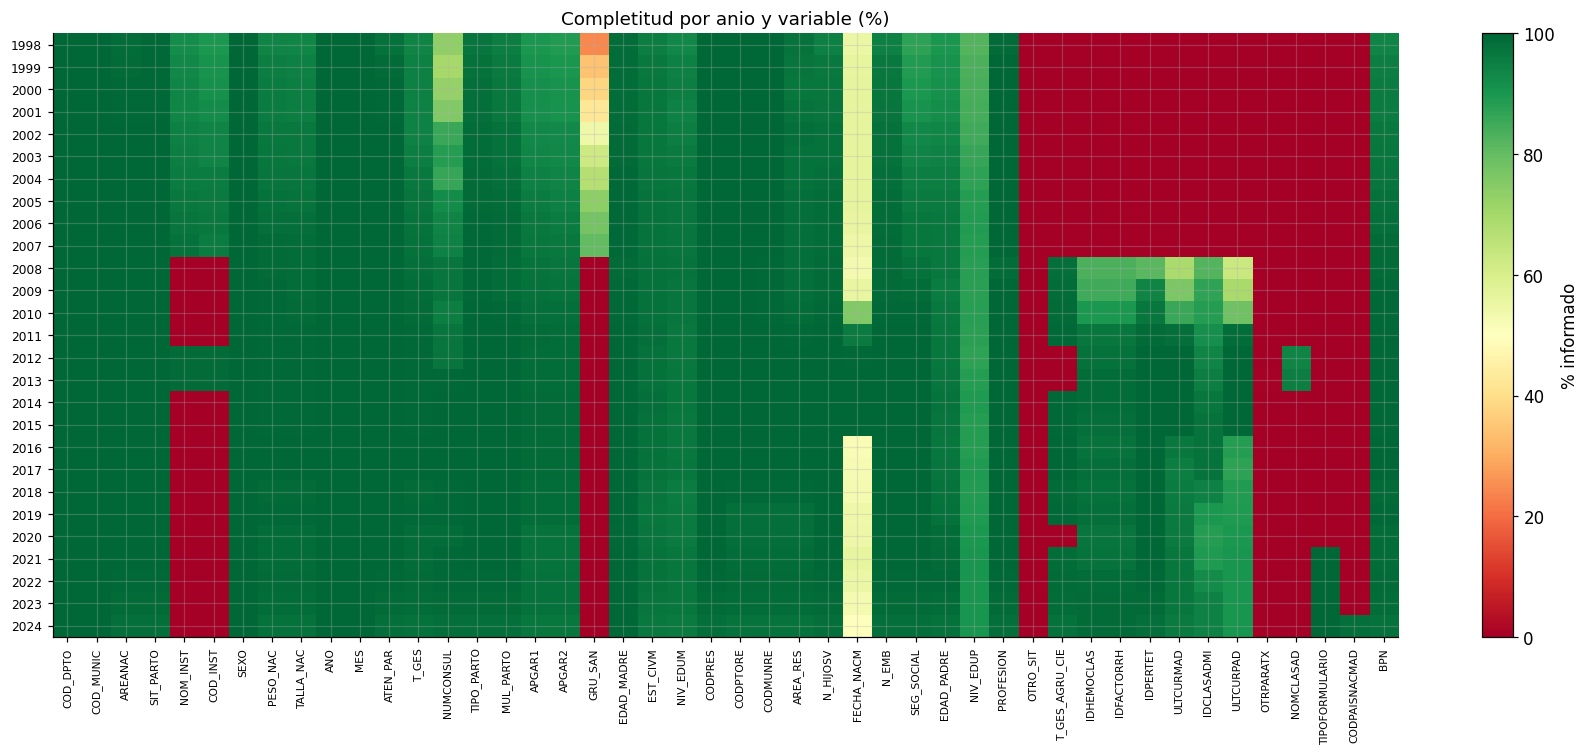


Variables con patron de AUSENCIA ESTRUCTURAL:
  NOM_INST           ausente en 15 anios: 2008-2024
  COD_INST           ausente en 15 anios: 2008-2024
  GRU_SAN            ausente en 17 anios: 2008-2024
  T_GES_AGRU_CIE     ausente en 13 anios: 1998-2020
  IDHEMOCLAS         ausente en 10 anios: 1998-2007
  IDFACTORRH         ausente en 10 anios: 1998-2007
  IDPERTET           ausente en 10 anios: 1998-2007
  ULTCURMAD          ausente en 10 anios: 1998-2007
  IDCLASADMI         ausente en 10 anios: 1998-2007
  ULTCURPAD          ausente en 10 anios: 1998-2007
  NOMCLASAD          ausente en 25 anios: 1998-2024
  TIPOFORMULARIO     ausente en 23 anios: 1998-2020
  CODPAISNACMAD      ausente en 26 anios: 1998-2023


In [4]:
# ---------------------------------------------------------------------------
# Completitud por anio
# ---------------------------------------------------------------------------

# Excluimos las columnas de control: son metadatos de la construccion, siempre
# estan al 100 % y solo anadirian filas planas al mapa de calor.
CONTROL_COLS = ["ANIO", "ARCHIVO_ORIGEN", "CATALOGO_DANE", "ESQUEMA_CODIGOS",
                "N_VARS_ORIGEN", "FILA_CORRIDA", "ES_DUPLICADO_EXACTO"]
sustantivas = [c for c in df.columns if c not in CONTROL_COLS]

with cronometro("completitud por anio"):
    # groupby("ANIO") y luego notna().mean() por grupo: da la proporcion de
    # informados de cada variable en cada anio. Es una sola pasada sobre la
    # base, que es lo que importa con 18 millones de filas.
    completitud = (
        df.groupby("ANIO")[sustantivas]
          .apply(lambda g: g.notna().mean())
          .mul(100)
          .round(1)
    )

guardar_tabla(completitud.reset_index(), "completitud_por_anio", decimales=1)

# Mapa de calor. Se usa imshow y no seaborn para no anadir una dependencia por
# una sola figura. aspect="auto" evita que las celdas salgan cuadradas y la
# figura quede desproporcionada con 27 filas y ~45 columnas.
fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(completitud.values, aspect="auto", cmap="RdYlGn",
               vmin=0, vmax=100)

ax.set_xticks(range(len(completitud.columns)))
ax.set_xticklabels(completitud.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(completitud.index)))
ax.set_yticklabels(completitud.index, fontsize=8)
ax.set_title("Completitud por anio y variable (%)")
fig.colorbar(im, ax=ax, label="% informado")

guardar_figura(fig, "completitud_por_anio")
plt.show()

# Clasificacion automatica. El criterio: si una variable esta por debajo del
# 5 % en algun anio Y por encima del 80 % en otro, no es ausencia aleatoria:
# es que el instrumento cambio.
print("\nVariables con patron de AUSENCIA ESTRUCTURAL:")
for col in completitud.columns:
    serie = completitud[col]
    if (serie < 5).any() and (serie > 80).any():
        anios_sin = serie.index[serie < 5].tolist()
        print(f"  {col:<18} ausente en {len(anios_sin)} anios: "
              f"{anios_sin[0]}-{anios_sin[-1]}")

**Cómo se lee esta salida.**

En el mapa de calor, **verde** es informado y **rojo** es ausente.

- **Bandas rojas horizontales completas** en un año: ese archivo llegó incompleto. Revisa
  el archivo original antes que el fenómeno.
- **Bloques rojos rectangulares** que cubren varios años seguidos en una columna: es
  **ausencia estructural**. Esa variable no existía en el formulario de esos años. Va a la
  lista de variables que no se imputan y se declara en las limitaciones.
- **Rojo disperso**, sin patrón temporal: ausencia por ítem. Candidata a imputación
  múltiple.
- **Etnia**: debe aparecer informada en 2012 y 2013. Si esos dos años salen rojos, el
  renombramiento a `IDPUEBLOIN` no se resolvió y se perdieron dos años enteros.
- **Fronteras verticales nítidas** en años concretos deben coincidir con los cortes de
  `ESQUEMA_CODIGOS`: 2008, 2012, 2014, 2020, 2021, 2024. Si hay una frontera donde no
  debería, hay un cambio de instrumento sin documentar, y **eso es hallazgo metodológico
  publicable**, no un estorbo.

**Qué va al manuscrito.** El mapa de calor como figura del Capítulo 4, y la lista de
variables con ausencia estructural en la Sección 4.3.3.

## 4. Conformación de la muestra analítica

**Qué hacemos.** Aplicamos las exclusiones en orden y contamos cuántos registros elimina
cada una. Es el diagrama de flujo de la **Tabla 4.1** del manuscrito.

**Por qué se cuenta paso a paso.** Un jurado va a preguntar cuántos registros se perdieron
y por qué. Una tabla que va de 18.008.809 a 17.376.860 en un solo paso no responde; una que
desglosa cada exclusión, sí. Además hace el filtro auditable: cualquiera puede reproducirlo.

**Las tres exclusiones y su justificación.**

1. **Duplicados exactos.** Registros idénticos en todos los campos. Marcados durante la
   construcción, no se detectan aquí.
2. **Incidencias de formato.** Filas corridas por un delimitador mal escapado en el archivo
   original. Sus valores están desplazados de columna y no son recuperables.
3. **Desenlace no observado.** Registros sin peso informado. **Salen del denominador**, no
   cuentan como peso normal. Contarlos como 0 sesgaría la prevalencia a la baja, y es un
   error frecuente al trabajar con esta fuente.

**Cifra de control.** Debe llegar a 17.376.860, el 96,49 %.

In [5]:
# ---------------------------------------------------------------------------
# Diagrama de flujo de exclusiones (Tabla 4.1)
# ---------------------------------------------------------------------------

# Las exclusiones NO se escriben aqui: se llaman desde src/datos.py.
#
# POR QUE IMPORTA: la version anterior de este notebook reimplementaba las
# exclusiones dentro de la celda. Al corregir datos.py, el notebook siguio
# aplicando las reglas viejas y la Tabla 4.1 quedo desfasada respecto al
# manuscrito SIN dar ningun error. Dos fuentes de verdad para la misma regla
# siempre acaban divergiendo; la unica proteccion es que haya una sola.
#
# detalle=True devuelve ademas el cuadro paso a paso, de modo que la Tabla 4.1
# del documento sale de la misma funcion que produce la muestra.
with cronometro("exclusiones"):
    muestra, tabla_4_1 = muestra_analitica(df, detalle=True)

guardar_tabla(tabla_4_1, "tabla_4_1_flujo_muestra", decimales=2)

# La muestra se persiste: los notebooks siguientes la releen en segundos en vez
# de repetir el filtro sobre 18 millones de filas.
guardar_intermedio(muestra, "muestra_analitica")

esperado = CONTROL["muestra_analitica"]
print(f"\nmuestra analitica : {len(muestra):,}")
print(f"manuscrito declara: {esperado:,}")
print("COINCIDE" if len(muestra) == esperado
      else f"DISCREPA en {len(muestra) - esperado:+,}")

tabla_4_1

[inicio] exclusiones
muestra analitica: 17,376,860 de 18,008,809 (96.49 %)
  manuscrito declara 17,376,860  ->  COINCIDE
[fin]    exclusiones  ->  21.0 s
tabla guardada: tabla_4_1_flujo_muestra.csv y tabla_4_1_flujo_muestra.tex
guardado: muestra_analitica.parquet  (17,376,860 filas)

muestra analitica : 17,376,860
manuscrito declara: 17,376,860
COINCIDE


,paso,excluidos,restantes,pct_sobre_base
0,Registros de la base 1998-2024,0,18008809,100.00
1,Peso al nacer no informado,332369,17676440,98.15
2,Edad gestacional no informada,207982,17468458,97.00
3,Residencia no identificable en Colombia,64431,17404027,96.64
4,Duplicados exactos,27103,17376924,96.49
5,Incidencias de formato,64,17376860,96.49


**Cómo se lee esta salida.**

La última fila de `restantes` debe ser **17.376.860**, y `pct_sobre_base` **96,49**.

**Las cuatro exclusiones, en este orden:**

| Exclusión | Criterio | Registros |
|---|---|---:|
| 1 | Peso al nacer no informado | 332.369 |
| 2 | Edad gestacional no informada | 207.982 |
| 3 | Residencia no identificable en Colombia | 64.431 |
| 4 | Duplicados exactos e incidencias de formato | 27.167 |

**Tres cosas que hay que saber defender de esta tabla.**

**La Exclusión 3 no retira solo los campos vacíos.** Entre 1998 y 2013 el territorio nunca
viene vacío: la ausencia se codifica con dos centinelas que no son departamentos reales.
`CODPTORE = 1` es «departamento ignorado» y `CODPTORE = 75` es **residencia en el exterior**,
donde el campo de municipio lleva en realidad el código del país. Un criterio que retirase
solo los nulos los dejaría dentro, y aparecerían en los mapas como si fueran territorios.

**El territorio es el de residencia, no el de ocurrencia.** Se filtra por `CODPTORE` y
`CODMUNRE`, no por `COD_DPTO` y `COD_MUNIC`. Una mujer de un municipio rural que da a luz en
un hospital de la capital pertenece a su municipio.

**La Exclusión 4 no estaba en la versión preliminar del cuadro.** Son duplicados exactos e
incidencias de formato que la construcción de la matriz identificó después. Por eso la
muestra difiere en 27.103 registros, el 0,16 %, respecto a aquella versión. La prevalencia
pasa del 8,82 al 8,78 %: ninguna conclusión cambia.

**Si discrepa:** las exclusiones las aplica `src/datos.py`, no esta celda. Ahí es donde hay
que mirar, y la cifra de control está en `src/config.py`.

**Qué va al manuscrito.** La tabla completa es el Cuadro 4.1. En el texto van el total, el
porcentaje retenido y la explicación de los dos centinelas.

## 5. El desenlace: prevalencia global

**Qué hacemos.** Frecuencia de `BPN` y prevalencia global sobre la muestra analítica.

**Por qué `BPN` no se recalcula.** Ya viene construido en la matriz, y hay una razón dura
para no tocarlo: **`PESO_NAC` en las EEVV no está en gramos**. Viene en ocho bandas de
500 g, y las cuatro primeras son las que caen por debajo de 2.500 g. Un código que hiciera
`PESO_NAC < 2500` estaría comparando un número de banda, entre 1 y 8, contra 2.500. El
resultado sería que **todos** los registros cuentan como bajo peso, y no daría ningún error.

Este es el punto donde el manuscrito tuvo que corregir una afirmación inicial, y conviene
tenerlo presente en la sustentación.

**Cifra de control.** 8,78 %.

In [6]:
# ---------------------------------------------------------------------------
# Distribucion del desenlace
# ---------------------------------------------------------------------------

# value_counts sobre la muestra. dropna=False para VER si quedo algun nulo:
# no deberia, porque la exclusion 3 los quito, y si aparece uno es que el
# filtro no se aplico.
conteo = muestra["BPN"].value_counts(dropna=False).sort_index()
print("Distribucion de BPN")
print(conteo)

# La prevalencia es la media de un indicador 0/1. mean() ignora nulos por
# defecto, que aqui es lo correcto: el denominador son los peso-informados.
prevalencia = muestra["BPN"].mean() * 100

print(f"\nPrevalencia global : {prevalencia:.2f} %")
print(f"Manuscrito declara : {CONTROL['prevalencia_global_pct']:.2f} %")
print(f"Casos de bajo peso : {int(muestra['BPN'].sum()):,}")

# Razon de desbalance. Se calcula aqui y no en la Fase 7 porque condiciona
# TODAS las decisiones del componente predictivo: con esta razon, un modelo que
# prediga siempre "no" acierta mas del 91 % y no sirve para nada.
n1 = int(muestra["BPN"].sum())
n0 = len(muestra) - n1
print(f"\nDesbalance         : {n0 / n1:.1f} negativos por cada positivo")
print(f"Exactitud del modelo trivial 'siempre no': {n0 / len(muestra) * 100:.2f} %")

Distribucion de BPN
BPN
0.0    15851088
1.0     1525772
Name: count, dtype: int64

Prevalencia global : 8.78 %
Manuscrito declara : 8.78 %
Casos de bajo peso : 1,525,772

Desbalance         : 10.4 negativos por cada positivo
Exactitud del modelo trivial 'siempre no': 91.22 %


**Cómo se lee esta salida.**

- **Solo debe haber dos valores**, 0 y 1. Si aparece un `NaN`, la exclusión 3 no se
  aplicó y todo lo que sigue está mal.
- La prevalencia debe ser **8,78 %**. Una diferencia en el segundo decimal es tolerable si
  la muestra coincide; una diferencia en el primero significa que el filtro es otro.
- **La última línea es la que hay que recordar para la sustentación.** Un modelo que
  prediga «ningún bebé tiene bajo peso» acierta más del 91 % de las veces. Por eso la
  Fase 7 usa área bajo la curva de precisión-sensibilidad y no exactitud, y por eso F₁
  tampoco sirve: F₁ supone que un falso positivo y un falso negativo cuestan lo mismo, y
  aquí no es así. No detectar un bebé en riesgo cuesta mucho más que una alerta de más.

**Qué va al manuscrito.** La prevalencia global a la primera frase de la Sección 5.1.2. La
razón de desbalance a la justificación de las métricas en la Sección 4.4.7.

## 6. Prevalencia anual con intervalo de confianza de Wilson

**Qué hacemos.** La proporción de bajo peso en cada uno de los 27 años, con intervalo del
95 %.

**Por qué es el bloque central del EDA.** Genera la **Figura 5.1** y es la serie sobre la
que se estima la tendencia del bloque siguiente.

**Por qué Wilson y no la aproximación normal.** La aproximación normal, `p ± 1,96·EE`,
construye el intervalo sumando y restando el error estándar. Con proporciones pequeñas eso
produce límites que se salen del rango [0, 1], y a veces límites inferiores negativos: una
prevalencia negativa no significa nada. Wilson resuelve la desigualdad del estadístico z
**para p**, de modo que el intervalo nunca sale del rango por construcción. Es el estándar
para proporciones y es lo que declara la Sección 4.4.1.

**Decisión que hay detrás.** El denominador son los nacidos vivos **con peso informado**, no
el total de registros del año. Es coherente con la exclusión 3 del bloque 4.

[inicio] prevalencia anual
[fin]    prevalencia anual  ->  0.5 s
guardado: prevalencia_anual.parquet  (27 filas)
tabla guardada: prevalencia_anual.csv y prevalencia_anual.tex
figura guardada: fig_5_1_prevalencia_anual.pdf y fig_5_1_prevalencia_anual.png


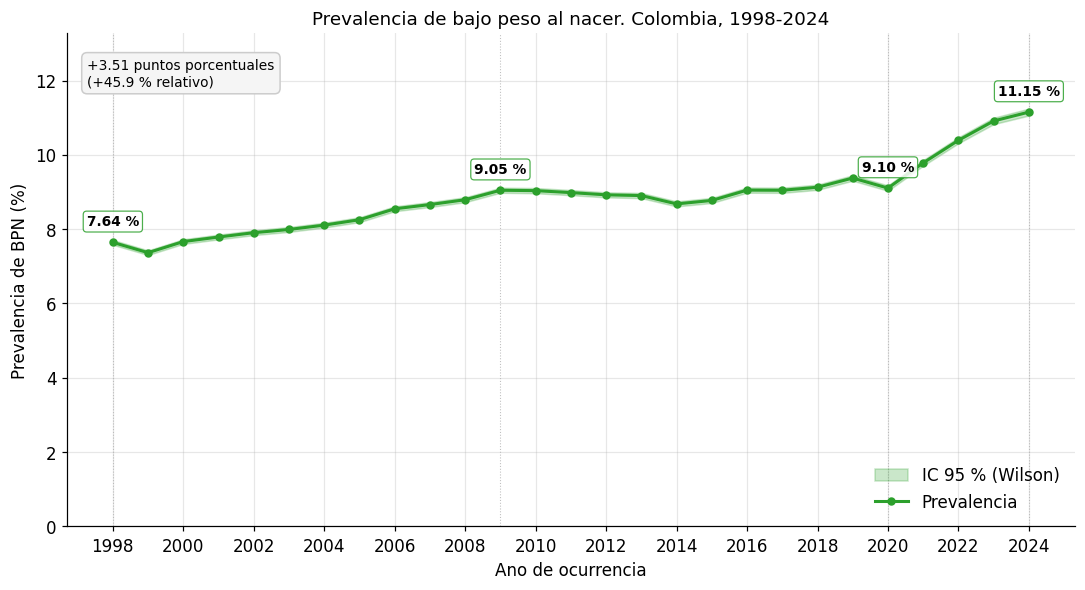


1998: 7.64 %
2024: 11.15 %
Cambio absoluto en el periodo: +3.51 puntos


,ANIO,n,casos,p_pct,ic_inf_pct,ic_sup_pct
0,1998,655015,50056.0,7.641962,7.577873,7.706548
1,1999,688975,50740.0,7.364563,7.303126,7.426476
2,2000,697070,53420.0,7.663506,7.601292,7.726186
3,2001,668203,52027.0,7.786107,7.722102,7.850597
4,2002,649822,51353.0,7.902626,7.837281,7.968468
5,2003,668053,53373.0,7.989336,7.924562,8.054594
6,2004,684698,55503.0,8.106202,8.041789,8.171084
7,2005,691149,57032.0,8.251766,8.187129,8.316867
8,2006,691381,59085.0,8.545939,8.480272,8.612068
9,2007,690525,59798.0,8.659788,8.593683,8.726353


In [7]:
# ---------------------------------------------------------------------------
# Prevalencia anual con intervalo de Wilson (Figura 5.1)
# ---------------------------------------------------------------------------

with cronometro("prevalencia anual"):
    # Una sola pasada: agg con dos funciones sobre la misma columna evita
    # recorrer los 17 millones de filas dos veces.
    #   sum  -> casos de bajo peso   (numerador)
    #   size -> nacidos con peso informado (denominador)
    res = (muestra.groupby("ANIO")["BPN"]
                  .agg(casos="sum", n="size")
                  .reset_index())

# Estimador puntual de la prevalencia.
res["p"] = res["casos"] / res["n"]

# --- Intervalo de Wilson ---------------------------------------------------
z = 1.959963985                                   # cuantil 0,975 de la normal
den = 1 + z**2 / res["n"]                         # denominador comun
centro = (res["p"] + z**2 / (2 * res["n"])) / den  # centro corregido: NO es p
margen = z * np.sqrt(
    res["p"] * (1 - res["p"]) / res["n"] + z**2 / (4 * res["n"]**2)
) / den
res["ic_inf"] = centro - margen
res["ic_sup"] = centro + margen

# A porcentaje SOLO para reportar. Los calculos posteriores siguen usando la
# proporcion, para no arrastrar factores de 100 por todo el analisis.
for c in ["p", "ic_inf", "ic_sup"]:
    res[c + "_pct"] = res[c] * 100

guardar_intermedio(res, "prevalencia_anual")
guardar_tabla(res[["ANIO", "n", "casos", "p_pct", "ic_inf_pct", "ic_sup_pct"]],
              "prevalencia_anual", decimales=2)

# --- Figura 5.1 ------------------------------------------------------------
#
# La figura tiene que poder leerse SIN el texto que la acompana. Un jurado la
# mira antes de leer el parrafo, y una serie sin cifras obliga a estimar los
# valores a ojo sobre el eje.
fig, ax = plt.subplots(figsize=(10, 5.5))

# La banda del intervalo va primero para que quede DEBAJO de la linea.
ax.fill_between(res["ANIO"], res["ic_inf_pct"], res["ic_sup_pct"],
                alpha=0.25, color="tab:green", label="IC 95 % (Wilson)")
ax.plot(res["ANIO"], res["p_pct"], marker="o", markersize=4.5,
        linewidth=2, color="tab:green", label="Prevalencia")

# --- Etiquetas de los anios clave ------------------------------------------
# No se etiquetan los 27: seria ilegible. Solo los extremos de la serie y los
# puntos de inflexion que el manuscrito declara (2009 y 2020). Son los unicos
# que se citan en el texto, de modo que la figura y el parrafo coinciden.
ANIOS_ETIQUETA = [1998, 2009, 2020, 2024]

for _, fila in res[res["ANIO"].isin(ANIOS_ETIQUETA)].iterrows():
    ax.annotate(
        f"{fila['p_pct']:.2f} %",
        xy=(fila["ANIO"], fila["p_pct"]),
        # Desplazamiento en PUNTOS, no en unidades del eje: asi la etiqueta
        # queda a la misma distancia visual aunque cambie la escala.
        xytext=(0, 11), textcoords="offset points",
        ha="center", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                  edgecolor="tab:green", alpha=0.85, linewidth=0.8),
    )
    # Linea vertical tenue para anclar la etiqueta a su ano en el eje.
    ax.axvline(fila["ANIO"], color="gray", linestyle=":", linewidth=0.7,
               alpha=0.5, zorder=0)

# --- Anotacion del cambio total --------------------------------------------
p_ini, p_fin = res["p_pct"].iloc[0], res["p_pct"].iloc[-1]
ax.annotate(
    f"{p_fin - p_ini:+.2f} puntos porcentuales\n"
    f"({(p_fin / p_ini - 1) * 100:+.1f} % relativo)",
    xy=(0.02, 0.95), xycoords="axes fraction",
    va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5",
              edgecolor="#cccccc"),
)

ax.set_xlabel("Año de ocurrencia")
ax.set_ylabel("Prevalencia de BPN (%)")
ax.set_title("Prevalencia de bajo peso al nacer. Colombia, 1998-2024")
# Ticks cada 2 anios: con 27 etiquetas el eje se solapa.
ax.set_xticks(range(1998, 2025, 2))
# Margen superior para que las etiquetas no choquen con el borde.
ax.set_ylim(bottom=0, top=res["ic_sup_pct"].max() * 1.18)
ax.legend(loc="lower right")

guardar_figura(fig, "fig_5_1_prevalencia_anual")
plt.show()

print(f"\n{int(res['ANIO'].iloc[0])}: {res['p_pct'].iloc[0]:.2f} %")
print(f"{int(res['ANIO'].iloc[-1])}: {res['p_pct'].iloc[-1]:.2f} %")
print(f"Cambio absoluto en el periodo: "
      f"{res['p_pct'].iloc[-1] - res['p_pct'].iloc[0]:+.2f} puntos")

res[["ANIO", "n", "casos", "p_pct", "ic_inf_pct", "ic_sup_pct"]]

**Cómo se lee esta salida.**

- El manuscrito reporta **7,64 % en 1998** y **11,15 % en 2024**. Si tu salida no reproduce
  esos extremos, el filtro no es el mismo; vuelve al bloque 4.
- **`n` debe crecer hasta cerca de 2008 y caer después.** La caída refleja el descenso real
  de la natalidad en Colombia. Un desplome abrupto y aislado en un solo año es sospecha
  sobre ese archivo, no sobre el fenómeno.
- **El ancho de la banda se estrecha cuando `n` crece.** Una banda ancha en un año con `n`
  grande es error de cálculo.
- La tendencia es **creciente**, lo cual es contraintuitivo: en un país que mejoró sus
  indicadores de salud materna en el período, el bajo peso al nacer sube. El bloque
  siguiente examina cuánto de eso es fenómeno y cuánto es artefacto del registro. **Es la
  pregunta que hizo el director y hay que llegar a la sustentación con la respuesta.**

**Qué va al manuscrito.** La figura es la Figura 5.1. Los valores de 1998 y 2024 van en la
primera frase de la Sección 5.1.4.

## 7. Tendencia temporal y amenaza a la validez

**Qué hacemos.** Dos cosas que van juntas y no deben separarse:

1. Estimamos el **cambio porcentual anual** con regresión de Poisson de varianza robusta.
2. Correlacionamos la prevalencia con el **volumen anual de registros**.

**Por qué juntas.** La tendencia sola sería un hallazgo engañoso. La cobertura del registro
civil colombiano cambió durante el período: se registran más nacimientos y se registran
mejor. Si los nacimientos que antes se escapaban del registro eran sistemáticamente
distintos, por ejemplo partos domiciliarios en zonas rurales, parte del aumento observado
es **artefacto de medición**, no aumento real del riesgo.

**Por qué Poisson y no regresión lineal sobre la proporción.** Poisson con varianza robusta
modela el conteo con el logaritmo del denominador como desplazamiento, lo que da
directamente un cambio **porcentual** anual, que es lo interpretable, y no obliga a suponer
varianza constante, que con `n` tan desiguales entre años sería falso.

**Cifras ya calculadas para contrastar:** cambio porcentual anual **+1,170 %**, puntos de
inflexión en **2009** y **2020**, correlación con el volumen **r = −0,853**.

**Este bloque no es opcional.** Es la respuesta a la primera pregunta del director, la de
si el tiempo importa. La respuesta que sostiene el manuscrito no es «el tiempo es un
hallazgo» sino «el tiempo es una **amenaza a la validez** que hay que acotar».

TENDENCIA TEMPORAL
  Cambio porcentual anual : +1.171 % (IC 95 %: +0.961 a +1.381)
  Valor p                 : 4.93e-28
  Manuscrito declara      : +1,170 %

AMENAZA A LA VALIDEZ: COBERTURA DEL REGISTRO
  Correlacion volumen-prevalencia : r = -0.851 (p = 1.84e-08)
  Manuscrito declara              : r = -0,853
figura guardada: fig_amenaza_cobertura.pdf y fig_amenaza_cobertura.png


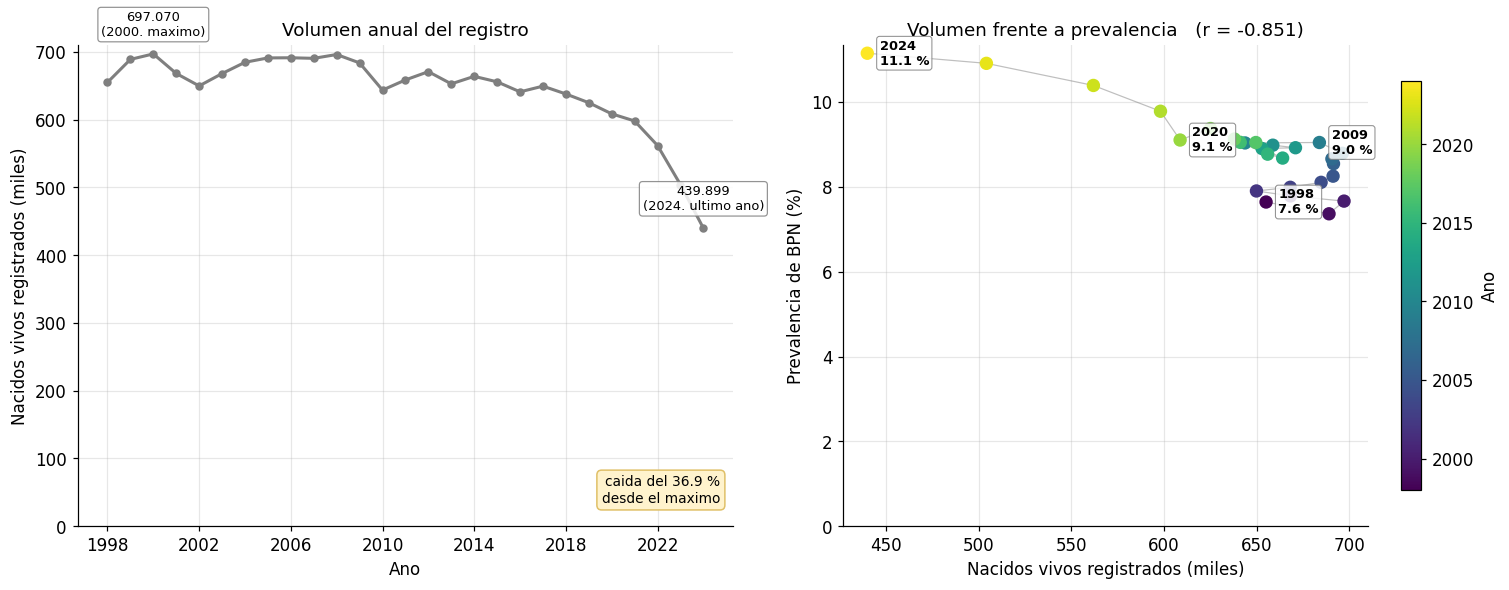

In [8]:
# ---------------------------------------------------------------------------
# Tendencia temporal (Poisson robusta) y correlacion con el volumen
# ---------------------------------------------------------------------------

import statsmodels.api as sm
from scipy import stats

# Centramos el anio en el inicio de la serie. Sin centrar, el intercepto seria
# el valor esperado en el anio 0 de la era comun, que no significa nada y
# ademas empeora el condicionamiento numerico.
res["anio_c"] = res["ANIO"] - res["ANIO"].min()

# add_constant anade la columna de unos del intercepto. statsmodels no la pone
# sola, a diferencia de otras bibliotecas, y olvidarla es un error clasico.
X = sm.add_constant(res[["anio_c"]])

# offset=log(n): modelamos el CONTEO de casos, pero el logaritmo del
# denominador entra como desplazamiento con coeficiente fijado en 1. Eso
# convierte el modelo de conteos en un modelo de TASAS, que es lo que
# queremos: la comparacion entre anios con denominadores muy distintos.
modelo = sm.GLM(res["casos"], X,
                family=sm.families.Poisson(),
                offset=np.log(res["n"])).fit(cov_type="HC0")
# cov_type="HC0": errores estandar robustos a la heterocedasticidad. Con
# sobredispersion, que es lo normal en datos reales, los errores de Poisson sin
# corregir son demasiado estrechos y todo sale significativo.

# El coeficiente esta en escala logaritmica. exp(b) - 1 lo convierte en el
# cambio proporcional por anio; x100, en porcentaje.
b = modelo.params["anio_c"]
cpa = (np.exp(b) - 1) * 100
ic = modelo.conf_int().loc["anio_c"]
cpa_ic = (np.exp(ic) - 1) * 100

print("TENDENCIA TEMPORAL")
print(f"  Cambio porcentual anual : {cpa:+.3f} % "
      f"(IC 95 %: {cpa_ic[0]:+.3f} a {cpa_ic[1]:+.3f})")
print(f"  Valor p                 : {modelo.pvalues['anio_c']:.2e}")
print(f"  Manuscrito declara      : +1,170 %")

# --- Amenaza a la validez: cobertura del registro --------------------------
# Correlacion de Pearson entre el volumen anual de registros y la prevalencia.
r, p = stats.pearsonr(res["n"], res["p"])
print("\nAMENAZA A LA VALIDEZ: COBERTURA DEL REGISTRO")
print(f"  Correlacion volumen-prevalencia : r = {r:.3f} (p = {p:.2e})")
print(f"  Manuscrito declara              : r = -0,853")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel izquierdo: volumen del registro ---------------------------------
axes[0].plot(res["ANIO"], res["n"] / 1000, marker="o", markersize=4.5,
             color="tab:gray", linewidth=2)
# Se etiquetan el maximo y el ultimo ano: son los dos puntos que se citan al
# describir la caida del registro.
i_max = res["n"].idxmax()
for idx, txt in [(i_max, "maximo"), (res.index[-1], "ultimo ano")]:
    fila = res.loc[idx]
    axes[0].annotate(
        f"{int(fila['n']):,}\n({int(fila['ANIO'])}, {txt})".replace(",", "."),
        xy=(fila["ANIO"], fila["n"] / 1000),
        xytext=(0, 12), textcoords="offset points",
        ha="center", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                  edgecolor="gray", alpha=0.85, linewidth=0.8))
caida = (1 - res["n"].iloc[-1] / res["n"].max()) * 100
axes[0].annotate(f"caida del {caida:.1f} %\ndesde el maximo",
                 xy=(0.98, 0.05), xycoords="axes fraction", ha="right",
                 fontsize=9, bbox=dict(boxstyle="round,pad=0.35",
                                       facecolor="#fff3cd", edgecolor="#e0c068"))
axes[0].set_xlabel("Año de ocurrencia")
axes[0].set_ylabel("Nacidos vivos registrados (miles)")
axes[0].set_title("Volumen anual del registro")
axes[0].set_xticks(range(1998, 2025, 4))
axes[0].set_ylim(bottom=0)

# --- Panel derecho: volumen frente a prevalencia ---------------------------
# El color codifica el ano: permite ver el RECORRIDO temporal de la nube, que
# es lo que convierte un diagrama de dispersion en una trayectoria.
sc = axes[1].scatter(res["n"] / 1000, res["p_pct"], s=60,
                     c=res["ANIO"], cmap="viridis", zorder=3)
# Linea que une los anios consecutivos: hace visible el sentido del recorrido.
axes[1].plot(res["n"] / 1000, res["p_pct"], color="gray", linewidth=0.8,
             alpha=0.5, zorder=2)
for _, fila in res.iterrows():
    if fila["ANIO"] in (1998, 2009, 2020, 2024):
        axes[1].annotate(
            f"{int(fila['ANIO'])}\n{fila['p_pct']:.1f} %",
            xy=(fila["n"] / 1000, fila["p_pct"]),
            xytext=(8, 0), textcoords="offset points",
            fontsize=8.5, fontweight="bold", va="center",
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                      edgecolor="gray", alpha=0.85, linewidth=0.7))
fig.colorbar(sc, ax=axes[1], label="Año", shrink=0.85)
axes[1].set_xlabel("Nacidos vivos registrados (miles)")
axes[1].set_ylabel("Prevalencia de BPN (%)")
axes[1].set_title(f"Volumen frente a prevalencia   (r = {r:.3f})")
axes[1].set_ylim(bottom=0)

guardar_figura(fig, "fig_amenaza_cobertura")
plt.show()

**Cómo se lee esta salida.**

- El **cambio porcentual anual** debe rondar **+1,170 %** (IC 95 %: +0,960 a +1,380). El intervalo no debe incluir el
  cero.
- El **valor p va a ser diminuto** y eso no significa nada: con 27 años y 17 millones de
  registros, cualquier pendiente distinta de cero sale significativa. **Lo que se
  interpreta es la magnitud**, no el valor p. Dilo así en la sustentación.
- La **correlación debe salir cerca de −0,853**, negativa y fuerte. Léela con cuidado:
  significa que **los años con más registros son los años con menor prevalencia**. Como el
  volumen creció y luego cayó, y la prevalencia subió, hay una confusión temporal entre
  cobertura del registro y riesgo.

**La lectura correcta.** No es «la prevalencia del bajo peso al nacer aumentó un 1,2 %
anual en Colombia». Es:

> *La prevalencia registrada aumentó un 1,170 % anual. El volumen del registro varió de
> forma sustancial en el mismo período y correlaciona con la prevalencia observada
> (r = −0,853), de modo que una parte no cuantificable de ese aumento puede corresponder a
> mejora de la cobertura y no a aumento del riesgo. Por esa razón el análisis principal es
> transversal-agrupado, el año entra como covariable de control, y la Fase 6 incluye un
> escenario que restringe la serie a los años de cobertura estable.*

Esa es la respuesta a la primera pregunta del director. **El tiempo no es el hallazgo: es
la amenaza que hay que acotar para que los demás hallazgos se sostengan.**

**Qué va al manuscrito.** Las dos figuras al Capítulo 5; el párrafo anterior, reescrito con
tus palabras, a las limitaciones del Capítulo 6.

## 8. Caracterización sociodemográfica

**Qué hacemos.** Para cada determinante social, su distribución y la prevalencia de bajo
peso dentro de cada categoría. Es la **Tabla 5.1**.

**Por qué estratificar por el desenlace.** La distribución sola describe la población; la
prevalencia por categoría es lo que empieza a mostrar el gradiente social, que es el objeto
de la tesis.

**Advertencia que debe acompañar a esta tabla.** Estas son diferencias **crudas**. No están
ajustadas por nada. Una diferencia de prevalencia entre niveles educativos puede deberse
por completo a la edad materna, si las madres de menor educación son sistemáticamente más
jóvenes. Aislar eso es trabajo de la Fase 4. **Aquí no se concluye nada causal.**

In [9]:
# ---------------------------------------------------------------------------
# Caracterizacion por determinante social (Tabla 5.1)
# ---------------------------------------------------------------------------

# Nombres canonicos del manuscrito. Filtramos contra las columnas reales
# porque la matriz tiene 53 y no todas se llaman igual que en el Capitulo 4;
# asi el notebook no revienta si falta alguna, solo la omite y avisa.
# La etnia se llama IDPERTET, no ETNIA: en 2012 y 2013 el DANE la nombro
# IDPUEBLOIN y la armonizacion la unifico bajo el primer nombre.
DETERMINANTES = ["NIV_EDUM", "NIV_EDUP", "SEG_SOCIAL", "EST_CIVM",
                 "AREA_RES", "IDPERTET", "SEXO", "MUL_PARTO", "TIPO_PARTO",
                 "SIT_PARTO"]

presentes = [c for c in DETERMINANTES if c in muestra.columns]
ausentes = [c for c in DETERMINANTES if c not in muestra.columns]
if ausentes:
    print(f"AVISO: no estan en la matriz y se omiten: {ausentes}")
    print("Comprueba como se llaman realmente antes de darlas por perdidas.\n")

bloques = []
for var in presentes:
    # dropna=False a proposito: queremos VER cuantos nulos hay en cada
    # determinante, porque es informacion sobre la calidad del dato.
    g = (muestra.groupby(var, dropna=False)["BPN"]
                .agg(n="size", casos="sum")
                .reset_index())
    g["prevalencia_pct"] = (g["casos"] / g["n"] * 100).round(2)
    g["pct_poblacion"] = (g["n"] / len(muestra) * 100).round(2)
    g.insert(0, "determinante", var)
    g = g.rename(columns={var: "categoria"})

    # --- Significado de cada codigo --------------------------------------
    # Una tabla de la tesis no puede pedirle al lector que tenga abierto el
    # diccionario del DANE para saber que es la categoria 3. La etiqueta se
    # anade aqui, tomada del modulo etiquetas.py, que la transcribe del
    # diccionario oficial.
    #
    # Cuando la variable NO esta armonizada, la etiqueta que se imprime es la
    # del regimen mas reciente y se marca, porque para los anios anteriores
    # ese mismo codigo significaba otra cosa. Marcarlo es lo unico honesto:
    # la alternativa seria una etiqueta valida solo para parte de la serie.
    marca = "" if etiquetas.armonizada(var) else "  [solo 2008-2024]"
    g.insert(2, "significado",
             [(etiquetas.etiqueta(var, c) or "sin documentar") + marca
              if pd.notna(c) else "(nulo)"
              for c in g["categoria"]])
    g["es_ausencia"] = [etiquetas.es_centinela(var, c) for c in g["categoria"]]

    bloques.append(g)

    # Razon entre la categoria de mayor y menor prevalencia. Es la primera
    # senal del gradiente social, aunque sea cruda.
    val = g.loc[g["n"] > 1000, "prevalencia_pct"]   # ignora categorias raras
    if len(val) > 1:
        print(f"{var:<12} prevalencia de {val.min():5.2f} % a {val.max():5.2f} %  "
              f"razon {val.max() / val.min():.2f}")

tabla_5_1 = pd.concat(bloques, ignore_index=True)
guardar_tabla(tabla_5_1, "tabla_5_1_caracterizacion", decimales=2)
tabla_5_1

C:\Users\ASUS\AppData\Local\Temp\ipykernel_968\3959624580.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (muestra.groupby(var, dropna=False)["BPN"]


NIV_EDUM     prevalencia de  7.17 % a 11.28 %  razon 1.57


C:\Users\ASUS\AppData\Local\Temp\ipykernel_968\3959624580.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (muestra.groupby(var, dropna=False)["BPN"]


NIV_EDUP     prevalencia de  7.53 % a 10.22 %  razon 1.36


C:\Users\ASUS\AppData\Local\Temp\ipykernel_968\3959624580.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (muestra.groupby(var, dropna=False)["BPN"]


...

C:\Users\ASUS\AppData\Local\Temp\ipykernel_968\3959624580.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (muestra.groupby(var, dropna=False)["BPN"]


TIPO_PARTO   prevalencia de  4.84 % a 12.29 %  razon 2.54


C:\Users\ASUS\AppData\Local\Temp\ipykernel_968\3959624580.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (muestra.groupby(var, dropna=False)["BPN"]


SIT_PARTO    prevalencia de  6.35 % a 15.74 %  razon 2.48
tabla guardada: tabla_5_1_caracterizacion.csv y tabla_5_1_caracterizacion.tex


,determinante,categoria,significado,n,casos,prevalencia_pct,pct_poblacion,es_ausencia
0,NIV_EDUM,1,Preescolar [solo 2008-2024],21453,1855.0,8.65,0.12,False
1,NIV_EDUM,2,Básica primaria [solo 2008-2024],1247551,96118.0,7.70,7.18,False
2,NIV_EDUM,3,Básica secundaria [solo 2008-2024],1265710,100975.0,7.98,7.28,False
3,NIV_EDUM,4,Media académica o clásica [solo 2008-2024],2151930,174161.0,8.09,12.38,False
4,NIV_EDUM,5,Media técnica [solo 2008-2024],1947817,159082.0,8.17,11.21,False
...,...,...,...,...,...,...,...,...
177,TIPO_PARTO,NaN,(nulo),37807,2645.0,7.00,0.22,False
178,SIT_PARTO,1,Institución de salud,17165683,1508284.0,8.79,98.78,False
179,SIT_PARTO,2,Domicilio,180775,12852.0,7.11,1.04,False
180,SIT_PARTO,3,Otro,28812,4535.0,15.74,0.17,False


**Cómo se lee esta salida.**

- **La razón entre categorías extremas es el gradiente crudo.** En nivel educativo materno
  esperamos ver la prevalencia más alta en las madres sin educación o con primaria
  incompleta. Si el gradiente sale plano o invertido, revisa la codificación de la variable
  antes de creerlo: puede que las categorías no estén ordenadas como supones.
- **Filtramos categorías con menos de 1.000 registros** al calcular la razón. Con
  denominadores pequeños, una categoría marginal produce prevalencias extremas por azar y
  distorsiona la lectura.
- **Si aparece una categoría `9` con frecuencia entre el 3 % y el 8 %**, ese es un valor
  centinela de «sin información» que sobrevivió a la recodificación. Es de los errores más
  frecuentes con esta fuente: entraría a los modelos como una categoría sustantiva y
  produciría un coeficiente que no se puede interpretar. Corrígelo antes de seguir.
- **La fila de nulos** de cada determinante dice cuánta imputación va a hacer falta en la
  Fase 6.

**Advertencia para el manuscrito.** Cualquier frase que acompañe a esta tabla debe decir
«prevalencia cruda» o «sin ajustar». Escribir aquí que un determinante «aumenta el riesgo»
sería atribuir causalidad a una tabla de contingencia, y es exactamente el tipo de frase
que un jurado subraya.

**Qué va al manuscrito.** La tabla es la Tabla 5.1 de la Sección 5.1.3.

## 8bis. Cómo cambian los determinantes en el tiempo

**Qué hacemos.** Dos cosas para cada determinante social, año a año:

1. **Composición** — qué porcentaje de las madres está en cada categoría
2. **Prevalencia por categoría** — el bajo peso dentro de cada grupo

**Por qué las dos juntas y no solo la segunda.** Es la distinción que sostiene toda la
descomposición de la Fase 5, y conviene verla antes.

La prevalencia nacional puede subir por dos motivos muy distintos. Puede que **cada grupo
empeore**, o puede que **la composición de la población cambie** y crezca el peso de los
grupos que ya estaban peor. Son fenómenos diferentes, exigen respuestas de política
distintas, y una sola serie nacional no los separa.

Esta es la figura que permite decir cuál de los dos está ocurriendo.

**Qué esperamos ver.** Colombia expandió la educación y la afiliación al régimen
contributivo durante el período. Si la composición mejora y aun así la prevalencia nacional
sube, el ascenso **no** se explica por la composición, y hay que buscarlo en otra parte —
incluida la cobertura del registro.

## La leyenda de códigos

Cada figura lleva un tercer panel con el significado de cada categoría, transcrito del
diccionario que el DANE publicó para cada catálogo. Sin él, el lector tendría que consultar
ese diccionario para saber qué es la categoría 3.

**Las líneas van rotuladas con el código y no con la etiqueta, y es deliberado.** Varios de
estos determinantes cambiaron de codificación en 2008: el mismo número pasó a significar
otra cosa. En el nivel educativo materno, el código 3 es «primaria incompleta» hasta 2007 y
«básica secundaria» desde 2008. Una línea rotulada «básica secundaria» que recorriera los
27 años afirmaría algo falso sobre la primera década. Lo que sí es común a toda la serie es
el código, de modo que el código va en la figura y la leyenda muestra **una columna por
régimen** cuando los regímenes discrepan.

Los códigos marcados con asterisco son **ausencia de dato**, no una categoría. Es la trampa
más cara de esta fuente: entran a un modelo como si fueran un nivel más y producen un
coeficiente que no significa nada.

NIV_EDUM: codigos NO unificados, la variable cambia de significado en 2008; el corte de la serie es real
figura guardada: fig_evolucion_NIV_EDUM.pdf y fig_evolucion_NIV_EDUM.png


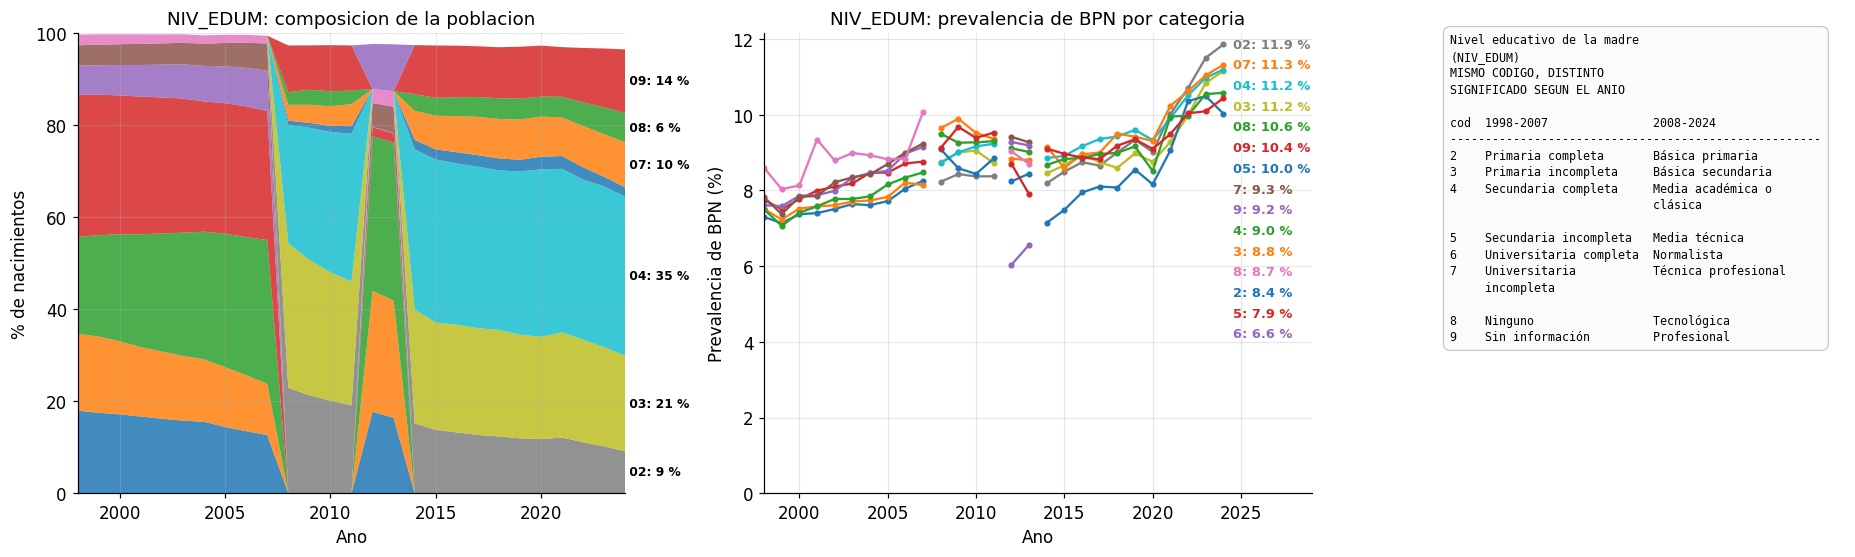

NIV_EDUM: NO se calcula el cambio de composicion 1998-2024.
   8 codigos cambian de significado en 2008: 2, 3, 4, 5, 6, 7, 8, 9
   Comparar los extremos de la serie compararia categorias
   distintas. Hace falta la escala comun antes de citar cifras.

SEG_SOCIAL: codigos NO unificados, la variable cambia de significado en 2008; el corte de la serie es real
figura guardada: fig_evolucion_SEG_SOCIAL.pdf y fig_evolucion_SEG_SOCIAL.png


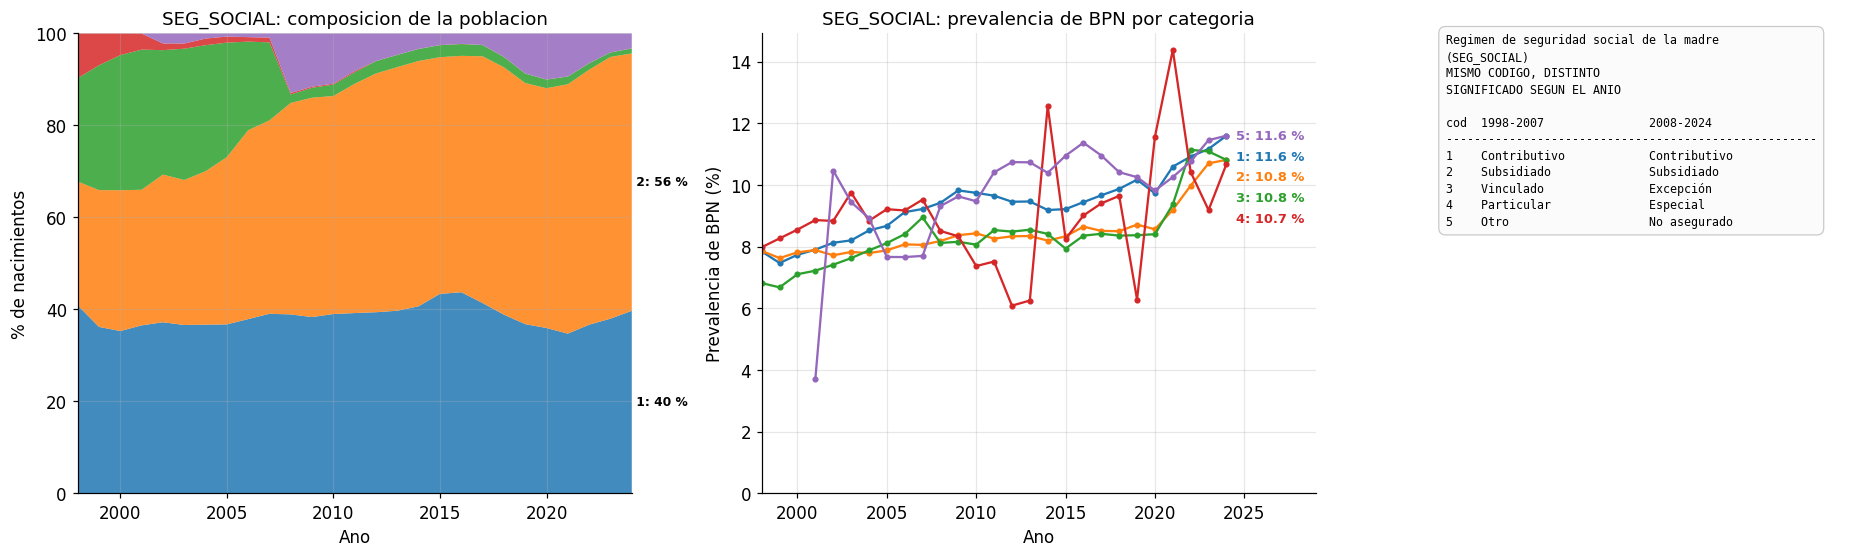

SEG_SOCIAL: NO se calcula el cambio de composicion 1998-2024.
   3 codigos cambian de significado en 2008: 3, 4, 5
   Comparar los extremos de la serie compararia categorias
   distintas. Hace falta la escala comun antes de citar cifras.

AREA_RES: codigos unificados (la variable esta armonizada)
figura guardada: fig_evolucion_AREA_RES.pdf y fig_evolucion_AREA_RES.png


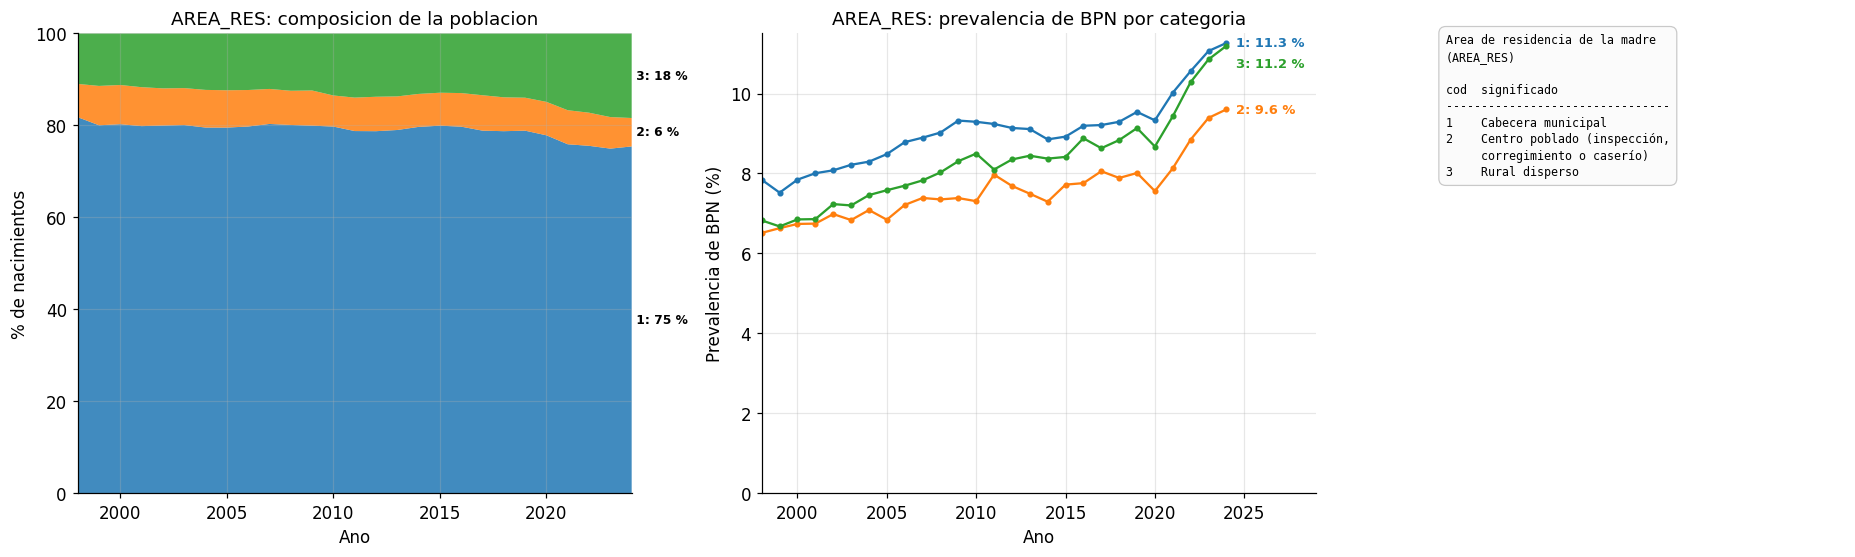

AREA_RES: cambio de composicion 1998-2024, en puntos porcentuales
   mas retrocede: 1 -6.4 pp
   mas avanza   : 3 +7.4 pp

EST_CIVM: codigos NO unificados, la variable cambia de significado en 2008; el corte de la serie es real
figura guardada: fig_evolucion_EST_CIVM.pdf y fig_evolucion_EST_CIVM.png


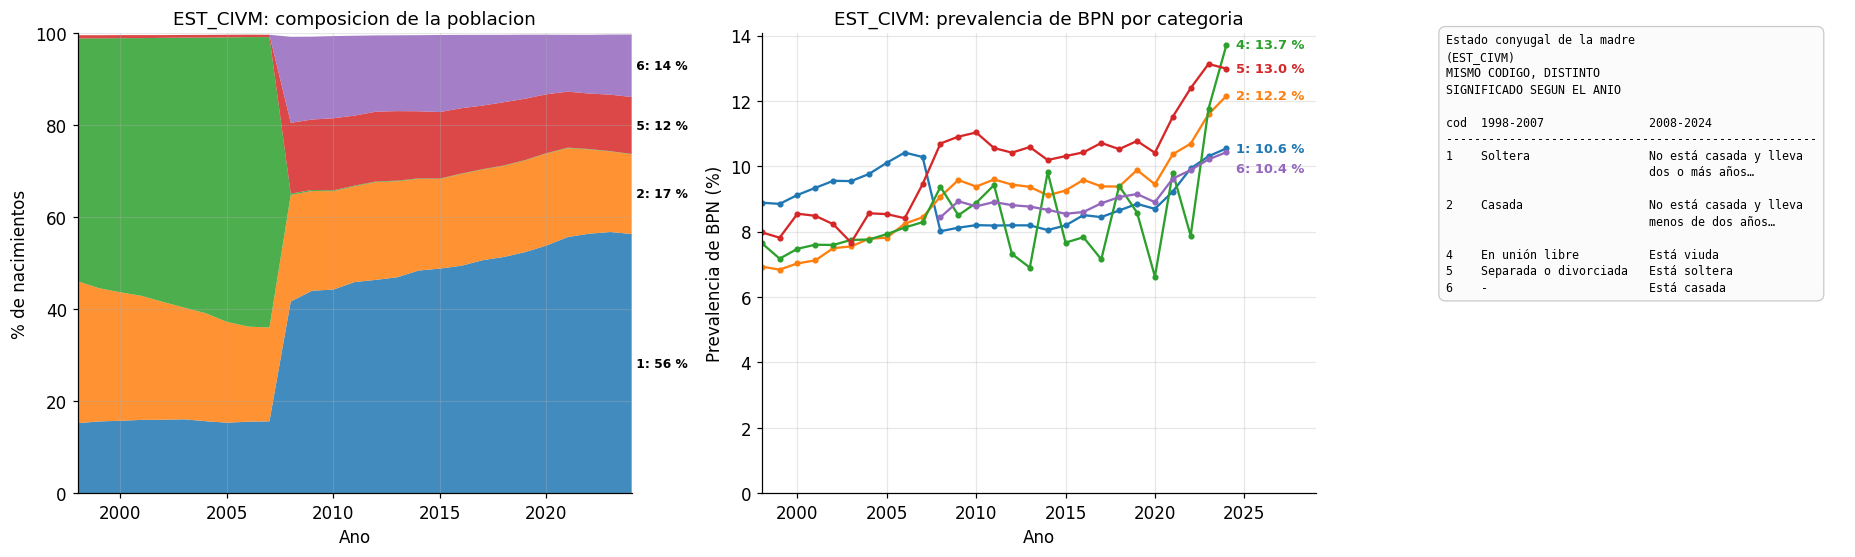

EST_CIVM: NO se calcula el cambio de composicion 1998-2024.
   5 codigos cambian de significado en 2008: 1, 2, 3, 4, 5
   Comparar los extremos de la serie compararia categorias
   distintas. Hace falta la escala comun antes de citar cifras.



In [10]:
# ---------------------------------------------------------------------------
# Evolucion temporal de los determinantes sociales
# ---------------------------------------------------------------------------

# Se grafican solo los determinantes con completitud razonable en toda la
# serie. Una variable con ausencia estructural produciria una linea que
# aparece de la nada a mitad del periodo y se leeria como un cambio real.
DETERMINANTES_EVOL = [v for v in ["NIV_EDUM", "SEG_SOCIAL", "AREA_RES", "EST_CIVM"]
                      if v in muestra.columns]

for var in DETERMINANTES_EVOL:
    # --- Relleno con ceros: cuando SI se puede unificar ---------------------
    #
    # EL PROBLEMA: hasta 2007 los codigos vienen como '1', '2', '3'; desde 2008
    # como '01', '02', '03'. Como texto son categorias distintas, de modo que
    # el mismo nivel dibuja DOS lineas, cada una en su tramo, y la serie
    # aparece cortada en 2008 sin que nada haya cambiado en la realidad.
    #
    # LA CONDICION: unificarlos solo es correcto si el codigo significa lo
    # mismo en los dos tramos. En NIV_EDUM no lo significa —el 3 pasa de
    # 'primaria incompleta' a 'basica secundaria'— y unir las dos lineas
    # dibujaria una continuidad FALSA: una sola serie que cambia de sujeto a
    # mitad de camino. En ese caso el corte visible es la lectura honesta, y se
    # deja.
    #
    # Por eso la normalizacion se aplica solo a las variables armonizadas.
    codigos_num = pd.to_numeric(muestra[var], errors="coerce")
    if etiquetas.armonizada(var) and codigos_num.notna().mean() > 0.99:
        # to_numeric ya colapso '01' y '1' en el mismo 1; se vuelve a texto
        # para que el eje y las etiquetas sigan mostrando el codigo.
        categoria = codigos_num.astype("Int64").astype("string")
        print(f"{var}: codigos unificados (la variable esta armonizada)")
    else:
        categoria = muestra[var]
        if not etiquetas.armonizada(var):
            print(f"{var}: codigos NO unificados, la variable cambia de "
                  f"significado en 2008; el corte de la serie es real")

    # --- Composicion: % de madres en cada categoria, por anio ---------------
    # normalize="index" da porcentajes POR FILA, es decir dentro de cada anio.
    comp = (pd.crosstab(muestra["ANIO"], categoria, normalize="index") * 100)

    # --- Prevalencia dentro de cada categoria, por anio ---------------------
    prev = (muestra.assign(_cat=categoria)
                   .groupby(["ANIO", "_cat"], observed=True)["BPN"]
                   .mean().mul(100).unstack())

    # Se conservan las categorias con al menos el 2 % de la poblacion en algun
    # anio: las mas raras anaden lineas ruidosas que no se pueden interpretar.
    frecuentes = comp.columns[comp.max() >= 2.0]
    # Las que se van. Se guardan para DECLARARLAS al pie de la tabla de
    # etiquetas: una figura que calla lo que omitio induce a creer que
    # muestra el total, y quien sume los porcentajes no llegara a cien.
    omitidas = [c for c in comp.columns if c not in set(frecuentes)]
    comp, prev = comp[frecuentes], prev.reindex(columns=frecuentes)

    # --- Tres paneles: los dos graficos y la leyenda de codigos -------------
    #
    # POR QUE LA LEYENDA VA EN UN EJE PROPIO Y NO EN fig.text():
    #   un eje participa del reparto de espacio que hace tight_layout, de modo
    #   que el texto nunca pisa el grafico ni se sale al exportar el PDF. Con
    #   fig.text() habria que ajustar los margenes a mano en cada figura.
    #
    # POR QUE LA LEYENDA Y NO ETIQUETAR DIRECTAMENTE LAS LINEAS:
    #   porque el codigo no significa lo mismo en todos los anios. En NIV_EDUM,
    #   el 3 es "Primaria incompleta" hasta 2007 y "Basica secundaria" desde
    #   2008. Una linea rotulada "Basica secundaria" que recorre los 27 anios
    #   seria una afirmacion falsa sobre la primera decada. La linea lleva el
    #   codigo, que es lo que de verdad es comun a toda la serie, y la leyenda
    #   muestra una columna por regimen cuando los regimenes discrepan.
    fig, axes = plt.subplots(
        1, 3, figsize=(17, 5.2),
        gridspec_kw={"width_ratios": [1, 1, 0.92]})

    # Panel izquierdo: composicion apilada. Apilada y no en lineas porque la
    # suma es 100 % y el area hace visible el reemplazo entre categorias.
    axes[0].stackplot(comp.index, [comp[c] for c in comp.columns],
                      labels=[str(c) for c in comp.columns], alpha=0.85)
    axes[0].set_ylim(0, 100)
    axes[0].set_xlim(comp.index.min(), comp.index.max())
    axes[0].set_title(f"{var}: composición de la población")
    axes[0].set_ylabel("% de nacimientos")
    axes[0].set_xlabel("Año de ocurrencia")

    # Etiqueta de cada categoria en el ultimo anio, dentro de su franja: evita
    # una leyenda aparte que obliga a ir y venir entre color y nombre.
    acum = 0
    for c in comp.columns:
        alto = comp[c].iloc[-1]
        if alto >= 6:   # solo si la franja es lo bastante ancha para el texto
            axes[0].text(comp.index.max(), acum + alto / 2, f" {c}: {alto:.0f} %",
                         va="center", fontsize=8, fontweight="bold")
        acum += alto

    # Panel derecho: prevalencia dentro de cada categoria.
    #
    # Las etiquetas de fin de linea se recogen primero y se dibujan DESPUES,
    # todas juntas. POR QUE: varias categorias terminan a alturas casi
    # identicas —diez, once y once coma dos por ciento— y anotarlas una por una
    # las deja superpuestas e ilegibles. etiquetar_fin_de_linea las separa lo
    # justo conservando el orden vertical de las series.
    finales, colores_serie = {}, {}
    for c in prev.columns:
        linea, = axes[1].plot(prev.index, prev[c], marker="o", markersize=3,
                              label=str(c))
        serie = prev[c].dropna()
        if len(serie):
            texto = f"{c}: {serie.iloc[-1]:.1f} %"
            finales[texto] = serie.iloc[-1]
            colores_serie[texto] = linea.get_color()

    axes[1].set_title(f"{var}: prevalencia de BPN por categoría")
    axes[1].set_ylabel("Prevalencia de BPN (%)")
    axes[1].set_xlabel("Año de ocurrencia")
    axes[1].set_ylim(bottom=0)
    # Margen a la derecha para que quepan las etiquetas de fin de linea.
    axes[1].set_xlim(prev.index.min(), prev.index.max() + 5)

    # Ahora si: las etiquetas, ya separadas entre si. Tiene que ir DESPUES de
    # fijar los limites del eje, porque la separacion se calcula como fraccion
    # del rango y ese rango cambia con set_ylim.
    etiquetar_fin_de_linea(axes[1], finales, x=prev.index.max(),
                           colores=colores_serie)

    # --- Panel derecho: que significa cada codigo ---------------------------
    # Se pasan SOLO los codigos dibujados. NIV_EDUM tiene catorce documentados
    # y la figura muestra cinco; una leyenda con los catorce obligaria al
    # lector a buscar cual esta mirando.
    etiquetas.tabla_leyenda(
        axes[2], var, codigos=list(comp.columns), omitidas=omitidas,
        nota_omitidas="no alcanzan el 2 % de la población en ningún año "
                      "de la serie, y su prevalencia sería ruido")

    fig.tight_layout()
    guardar_figura(fig, f"fig_evolucion_{var}")
    plt.show()

    # --- Cifras para el texto ----------------------------------------------
    # El cambio de composicion en puntos porcentuales entre el primer y el
    # ultimo anio. Es lo que se cita para decir si la poblacion cambio.
    #
    # PERO SOLO SI LA VARIABLE ESTA ARMONIZADA. Restar el porcentaje del
    # codigo 3 en 2024 menos el del codigo 3 en 1998, cuando ese codigo
    # cambio de significado, no mide un cambio de la poblacion: mide un
    # cambio del formulario. Es una resta que da un numero perfectamente
    # plausible y completamente vacio, y por eso hay que bloquearla en el
    # codigo y no confiar en recordarlo al escribir.
    if etiquetas.armonizada(var):
        cambio = (comp.iloc[-1] - comp.iloc[0]).sort_values()
        print(f"{var}: cambio de composicion 1998-2024, en puntos porcentuales")
        print(f"   mas retrocede: {cambio.index[0]} {cambio.iloc[0]:+.1f} pp")
        print(f"   mas avanza   : {cambio.index[-1]} {cambio.iloc[-1]:+.1f} pp")
    else:
        conf = etiquetas.conflictos(var)
        print(f"{var}: NO se calcula el cambio de composicion 1998-2024.")
        print(f"   {len(conf)} codigos cambian de significado en 2008: "
              f"{', '.join(sorted(conf, key=lambda c: (len(c), c)))}")
        print("   Comparar los extremos de la serie compararia categorias")
        print("   distintas. Hace falta la escala comun antes de citar cifras.")
    print()

**Cómo se lee esta salida.**

**Panel izquierdo, composición.** Cada franja es una categoría y la suma es 100 %. Lo que
hay que mirar es el **reemplazo**: qué franja se estrecha y cuál se ensancha. En nivel
educativo materno, lo esperable es que las categorías bajas se estrechen a lo largo del
período.

**Panel derecho, prevalencia por categoría.** Aquí está la pregunta importante:

- **Si todas las líneas suben en paralelo**, el deterioro afecta a todos los grupos por
  igual. La desigualdad relativa se mantiene y el ascenso nacional no es composicional.
- **Si las líneas se separan**, la desigualdad **se amplía**: unos grupos empeoran más que
  otros. Ese sería un hallazgo de primer orden para la tesis.
- **Si convergen**, la desigualdad se reduce aunque el nivel suba.

**Y el cruce de los dos paneles es lo que da el argumento.** Si la composición mejora —menos
madres en las categorías desfavorecidas— y aun así la prevalencia nacional sube, entonces el
ascenso **no** se explica por un empeoramiento de la estructura social de la población. Hay
que buscarlo en otra parte, y la cobertura del registro es el primer candidato, con la
correlación de −0,853 que ya se calculó.

**Precaución.** Estas son prevalencias crudas dentro de cada categoría, sin ajustar por
nada. Que un grupo tenga prevalencia más alta puede deberse por completo a su composición
por edad materna o por territorio. Separar eso es trabajo de la Fase 4.

**Qué va al manuscrito.** Una de las figuras —probablemente la de nivel educativo materno—
al Capítulo 5, Sección 5.1.3. El resto al apéndice. En el texto, las cifras de cambio de
composición que imprime la celda, y la frase sobre si las líneas convergen, divergen o van
en paralelo.

## 8ter. Coherencia de las categorías entre regímenes de codificación

**Qué hacemos.** Para cada determinante, comparamos **qué categorías existen** en cada
valor de `ESQUEMA_CODIGOS`.

**Por qué este bloque existe.** Lo descubrió la figura anterior. En el panel de composición,
las franjas daban saltos verticales en 2008 y en 2012: no es que la población cambiara de
golpe, es que **las categorías dejaron de ser las mismas**.

**La distinción que hay que tener clarísima.** La armonización del crosswalk resolvió los
**nombres** de las variables: `IDPERTET` y `IDPUEBLOIN` son la misma cosa y ahora se llaman
igual. Pero eso no garantiza que los **valores** signifiquen lo mismo. Una variable puede
llamarse igual en los 27 años y codificar cosas distintas en cada régimen.

**Por qué invalida el análisis si no se resuelve.** Si el código `3` significa una cosa en
2003 y otra en 2015, cualquier análisis que agrupe los años está sumando categorías que no
son comparables. El índice de concentración, los modelos multinivel y los clasificadores
heredan el problema, y ninguno de ellos daría error: darían resultados sin sentido.

In [11]:
# ---------------------------------------------------------------------------
# Coherencia de categorias entre regimenes de codificacion
# ---------------------------------------------------------------------------

# --- Lo que dice el DICCIONARIO del DANE -----------------------------------
#
# Esta comprobacion es documental, no empirica: compara los diccionarios que
# el DANE publico para cada catalogo y detecta que codigos cambiaron de
# significado. Se hace ANTES que la comprobacion sobre los datos porque
# responde a una pregunta distinta y mas fuerte.
#
#   sobre los datos      -> que categorias APARECEN en cada regimen
#   sobre el diccionario -> que SIGNIFICA cada categoria en cada regimen
#
# La segunda es la que importa. Una variable puede presentar los mismos
# codigos en los 27 anios y ser inutilizable porque esos codigos significan
# cosas distintas. Los datos por si solos nunca revelan eso.
informe = etiquetas.informe_armonizacion(
    [v for v in ["NIV_EDUM", "NIV_EDUP", "SEG_SOCIAL", "EST_CIVM", "AREA_RES",
                 "IDPERTET", "T_GES", "MUL_PARTO", "TIPO_PARTO", "SIT_PARTO",
                 "SEXO"] if v in muestra.columns])
guardar_tabla(informe, "armonizacion_diccionario_dane", decimales=0)

print("SEGUN EL DICCIONARIO DEL DANE")
print(informe[["variable", "codificaciones", "armonizada",
               "codigos_en_conflicto", "cuales"]].to_string(index=False))

# El detalle de cada codigo que cambia de significado. Es el material del
# mapeo que hay que construir, escrito para poder copiarlo al apendice.
for var in informe.loc[~informe["armonizada"], "variable"]:
    print(f"\n{var} — {etiquetas.NOMBRES.get(var, '')}")
    for cod, vistas in etiquetas.conflictos(var).items():
        detalle = "   |   ".join(f"[{rot}] {eti or '(no existe)'}"
                                 for rot, eti in vistas.items())
        print(f"   codigo {cod:>2}:  {detalle}")

print("\n" + "=" * 70 + "\n")

# --- Lo que dicen los DATOS -------------------------------------------------
if "ESQUEMA_CODIGOS" not in muestra.columns:
    print("AVISO: falta ESQUEMA_CODIGOS; no se puede comprobar la coherencia.")
else:
    filas = []
    for var in DETERMINANTES_EVOL:
        # Conjunto de categorias presentes en cada regimen.
        por_esq = (muestra.groupby("ESQUEMA_CODIGOS", observed=True)[var]
                          .apply(lambda s: frozenset(s.dropna().unique())))
        # Regimen de referencia: el que cubre mas anios recientes.
        referencia = por_esq.get("2021-2023", por_esq.iloc[0])

        for esq, cats in por_esq.items():
            filas.append({
                "variable": var,
                "esquema": esq,
                "n_categorias": len(cats),
                "iguales_a_referencia": cats == referencia,
                # Simetrica: lo que sobra en uno y falta en el otro.
                "n_discrepantes": len(cats ^ referencia),
                "ejemplos": ", ".join(sorted(map(str, cats))[:8]),
            })

    coherencia = pd.DataFrame(filas)
    guardar_tabla(coherencia, "coherencia_categorias", decimales=0)

    # --- Resumen: que variables NO estan armonizadas en valores -------------
    problema = (coherencia.groupby("variable")["iguales_a_referencia"]
                          .apply(lambda s: (~s).sum()))
    print("VARIABLES CUYAS CATEGORIAS CAMBIAN ENTRE REGIMENES")
    print("(numero de regimenes que difieren del de referencia)\n")
    for var, n in problema.sort_values(ascending=False).items():
        marca = "  *** NO ARMONIZADA ***" if n > 0 else "  armonizada"
        print(f"  {var:<12} {n} de {len(coherencia[coherencia.variable==var])}{marca}")

    # --- Cuanta muestra esta en regimenes no alineados ----------------------
    peso = (muestra["ESQUEMA_CODIGOS"].value_counts(normalize=True) * 100).round(1)
    print("\n\nPESO DE CADA REGIMEN EN LA MUESTRA")
    print(peso.to_string())

    afectados = coherencia.loc[~coherencia["iguales_a_referencia"], "esquema"].unique()
    pct = float(peso.reindex(afectados).sum())
    print(f"\nregistros en regimenes con categorias discrepantes: {pct:.1f} % de la muestra")

    if pct > 20:
        print("\n" + "!" * 66)
        print("ESTO BLOQUEA LAS FASES 3 A 7.")
        print("Antes de calcular el indice de concentracion, ajustar los modelos")
        print("multinivel o entrenar los clasificadores, hay que definir una escala")
        print("comun por variable y recodificar cada regimen a esa escala.")
        print("Agrupar los anios sin hacerlo suma categorias que no son comparables.")
        print("!" * 66)

    coherencia

tabla guardada: armonizacion_diccionario_dane.csv y armonizacion_diccionario_dane.tex
SEGUN EL DICCIONARIO DEL DANE
  variable  codificaciones  armonizada  codigos_en_conflicto                 cuales
  NIV_EDUM               2       False                     8 2, 3, 4, 5, 6, 7, 8, 9
  NIV_EDUP               2       False                     8 2, 3, 4, 5, 6, 7, 8, 9
  EST_CIVM               2       False                     5          1, 2, 3, 4, 5
SEG_SOCIAL               2       False                     3                3, 4, 5
  AREA_RES               1        True                     0                       
  IDPERTET               1        True                     0                       
     T_GES               1        True                     0                       
 MUL_PARTO               1        True                     0                       
TIPO_PARTO               1        True                     0                       
 SIT_PARTO               1        True      

**Cómo se lee esta salida.**

**La columna `iguales_a_referencia`** es la respuesta. Si sale `False` para algún régimen,
esa variable **no está armonizada en valores** y no se puede agrupar entre años sin
recodificar.

**Lo que hay que mirar en `ejemplos`:**

- Si un régimen tiene `1,2,3,4,5` y otro `01,02,03,04,05`, el problema es solo el relleno
  con ceros y se arregla normalizando el formato.
- Si un régimen tiene **cinco** categorías y otro **trece**, el instrumento cambió y hace
  falta un mapeo conceptual: decidir qué categorías del esquema detallado corresponden a
  cada categoría del esquema agregado.
- Si aparecen valores de tres cifras donde debería haber una o dos, la variable está
  **contaminada** con códigos de otra —país, por ejemplo— y hay que aislarlos.

**El porcentaje de muestra afectada decide la gravedad.** Por debajo del 5 % puede tratarse
como faltante y declararse. Por encima del 20 % no hay atajo: hay que construir la escala
común.

**Las dos comprobaciones responden a preguntas distintas y hacen falta las dos.**

| | Pregunta | Qué detecta |
|---|---|---|
| **Diccionario** | qué **significa** cada código en cada régimen | que un código cambie de sentido conservando el nombre de la variable |
| **Datos** | qué códigos **aparecen** en cada régimen | que una categoría se use en la práctica, o que aparezca una no documentada |

La primera es la más fuerte, y es la que ninguna inspección de los datos puede sustituir:
una variable puede presentar exactamente los mismos códigos en los 27 años y ser
inutilizable porque esos códigos significan cosas distintas. Sobre los datos, eso no deja
ninguna huella.

**El resultado de esta sección, en una frase.** La armonización de la matriz resolvió la
correspondencia entre **nombres** de variable a lo largo de los seis regímenes de
codificación; la correspondencia entre **valores** es un problema distinto, y en cuatro
determinantes —nivel educativo de la madre y del padre, estado conyugal y régimen de
seguridad social— no está resuelta. Una variable puede conservar el nombre y cambiar el
conjunto de categorías que codifica, y eso es lo que ocurrió en 2008.

**El caso más caro.** En el nivel educativo materno, el código `9` significa «sin
información» entre 1998 y 2007 y «profesional» desde 2008. Un análisis que agrupara los
años sin recodificar estaría mezclando la ausencia de dato con el segundo nivel educativo
más alto de la escala, y produciría un gradiente social invertido en la parte alta de la
distribución sin emitir ningún aviso.

**Correspondencia con el manuscrito.** Las dos tablas al Capítulo 4, sección de
armonización, y el mapeo que se construya al Apéndice. Es material de defensa: documenta
una limitación de la fuente que la mayoría de los trabajos con EEVV no examina.

## 9. Matriz de asociación entre variables: V de Cramér

**Qué hacemos.** Dos cosas con la misma medida:

1. La asociación de **cada determinante con el desenlace**, que ordena las candidatas por
   cuánto se relacionan con el bajo peso al nacer.
2. La **matriz de asociación entre los determinantes**, que es el diagnóstico de
   colinealidad: qué variables miden en buena parte lo mismo.

**Por qué V de Cramér y no correlación de Pearson.** Todos los determinantes de este
trabajo son categóricos, y varios no están ordenados: el régimen de seguridad social, el
reconocimiento étnico y el estado conyugal no tienen un orden natural. Un coeficiente de
Pearson sobre esos códigos mediría la relación lineal entre **números de etiqueta**, que es
una cantidad sin significado — bastaría renumerar las categorías para obtener otro
resultado. La V de Cramér se construye sobre la tabla de contingencia y solo usa
frecuencias conjuntas, de modo que renumerar no la altera. Es la medida que define la
Sección 3.4.1 del marco teórico.

$$V=\sqrt{\frac{\chi^{2}/n}{\min(r-1,\;k-1)}}$$

**Por qué se corrige el sesgo.** La V sin corregir crece con el número de categorías aunque
las dos variables sean independientes: una variable de catorce niveles parece más asociada
que una de tres solo por tener más niveles, y aquí se comparan variables de 2 a 14
categorías en la misma matriz. Se aplica la corrección de **Bergsma (2013)**, que resta el
sesgo esperado bajo independencia. Con diecisiete millones de filas el ajuste es diminuto;
se aplica igual porque el mismo módulo se reutiliza en los análisis por año y por
departamento, donde los denominadores son mucho menores y el sesgo sí pesa.

**La advertencia que acompaña a esta salida.** Con diecisiete millones de registros
**todas** las pruebas χ² salen significativas, incluso las asociaciones triviales. El valor
p aquí no distingue nada: es una función del tamaño muestral. **Lo que se interpreta es la
magnitud de V**, no el valor p. Por eso la tabla los reporta juntos y la lectura solo usa V.

**Por qué entran el departamento y el municipio.** El territorio es uno de los tres ejes de
desigualdad del título, junto al socioeconómico y el étnico, y la V de Cramér es la única
medida de esta sección que se le puede aplicar: no está ordenado ni se puede tratar como
continuo. Entra como **residencia de la madre**, no como lugar de ocurrencia del parto,
coherente con la Exclusión 3.

Dos precauciones al leer esas dos filas:

- **El código de municipio no es único en el país.** En las EEVV el municipio se numera
  dentro de su departamento, así que el `001` existe en los treinta y tres. Se compone el
  código DIVIPOLA —departamento × 1000 + municipio— antes de calcular nada. Sin esa
  composición, la V del municipio sería un número sin significado.
- **La V entre departamento y municipio vale 1 por construcción**, porque el municipio
  determina el departamento. No es un hallazgo; es una comprobación: si **no** diera 1, el
  código DIVIPOLA estaría mal formado y el error se propagaría a los mapas y al modelo
  multinivel. Por eso el par se excluye de la lista de vigilancia y se reporta aparte.

Y una advertencia sobre la magnitud: el municipio tiene más de mil categorías, de modo que
su V sin corregir saldría inflada solo por la cardinalidad. Es el caso donde la corrección
de Bergsma deja de ser un detalle. Aun corregida, **la V territorial no es comparable de
forma directa con la de una variable de tres categorías**: mide sobre una partición mucho
más fina. Se lee como orden de magnitud, y la cuantificación seria de la desigualdad
territorial es el índice de concentración de la Fase 3 y la varianza entre conglomerados
del modelo multinivel de la Fase 4.

**Qué NO es esta matriz.** No es la matriz de interacción de la Fase 2. Aquella mide si dos
variables **juntas** informan sobre el desenlace más que por separado, que es sinergia. Esta
mide cuánto se solapan **entre sí**, sin mirar el desenlace, que es redundancia. Dos
variables pueden estar muy asociadas entre sí y aun así aportar información complementaria
sobre el bajo peso al nacer; la decisión de eliminar una de ellas la toma el cribado por
información mutua condicional, no esta matriz. Aquí solo se documenta la estructura de
asociación.

departamentos de residencia: 33
municipios de residencia   : 1,157

variables en la matriz: 17
pares a calcular      : 136

[inicio] V de Cramer contra BPN
[fin]    V de Cramer contra BPN  ->  16.0 s
tabla guardada: v_cramer_contra_bpn.csv y v_cramer_contra_bpn.tex
ASOCIACION DE CADA VARIABLE CON EL BAJO PESO AL NACER
  variable  v_cramer  categorias  completitud_pct
     T_GES    0.4645           5         100.0000
 MUL_PARTO    0.2419           4          99.3100
TIPO_PARTO    0.0996           4          99.7800
 NUMCONSUL    0.0919          55          93.8200
  MUNI_RES    0.0764        1157         100.0000
  DPTO_RES    0.0685          33         100.0000
EDAD_MADRE    0.0328           9          99.8000
  EST_CIVM    0.0279           6          97.7900
     N_EMB    0.0277          24          99.3100
      SEXO    0.0266           3         100.0000
  NIV_EDUP    0.0259          22          88.3500
  NIV_EDUM    0.0240          22          96.8000
  N_HIJOSV    0.0223          

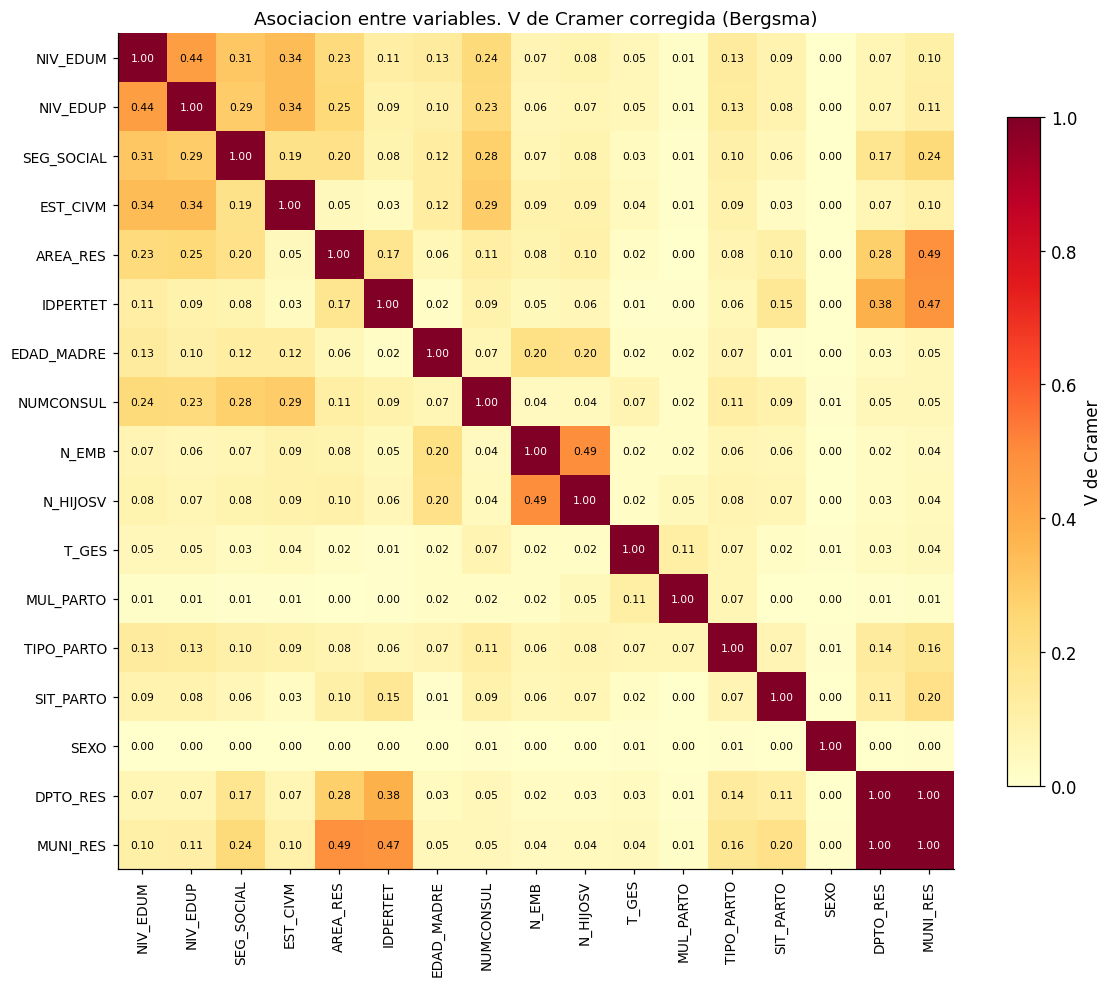

comprobacion del anidamiento territorial: V(DPTO, MUNI) = 1.0000
tabla guardada: pares_asociacion_alta.csv y pares_asociacion_alta.tex

PARES CON V >= 0.30
  N_EMB        N_HIJOSV     V = 0.494
  AREA_RES     MUNI_RES     V = 0.485
  IDPERTET     MUNI_RES     V = 0.472
  NIV_EDUM     NIV_EDUP     V = 0.438
  IDPERTET     DPTO_RES     V = 0.378
  NIV_EDUM     EST_CIVM     V = 0.342
  NIV_EDUP     EST_CIVM     V = 0.340
  NIV_EDUM     SEG_SOCIAL   V = 0.305


,variable_1,variable_2,v_cramer
0,N_EMB,N_HIJOSV,0.4936
1,AREA_RES,MUNI_RES,0.4851
2,IDPERTET,MUNI_RES,0.4725
3,NIV_EDUM,NIV_EDUP,0.4380
4,IDPERTET,DPTO_RES,0.3779
5,NIV_EDUM,EST_CIVM,0.3415
6,NIV_EDUP,EST_CIVM,0.3403
7,NIV_EDUM,SEG_SOCIAL,0.3053


In [12]:
# ---------------------------------------------------------------------------
# Asociacion entre variables: V de Cramer con correccion de Bergsma
# ---------------------------------------------------------------------------

DETERMINANTES_ASOC = [v for v in
                      ["NIV_EDUM", "NIV_EDUP", "SEG_SOCIAL", "EST_CIVM",
                       "AREA_RES", "IDPERTET",
                       "EDAD_MADRE", "NUMCONSUL", "N_EMB", "N_HIJOSV", "T_GES",
                       "MUL_PARTO", "TIPO_PARTO", "SIT_PARTO", "SEXO"]
                      if v in muestra.columns]

# --- Las dos variables territoriales ---------------------------------------
#
# Se construyen aqui, no se toman en bruto, por dos razones.
#
# PRIMERA, EL CODIGO DE MUNICIPIO NO ES UNICO EN EL PAIS. En las EEVV el
# municipio se numera DENTRO de su departamento: el 001 existe en los treinta y
# tres. Usar CODMUNRE tal cual fundiria en una sola categoria municipios de
# extremos opuestos del pais, y la V resultante seria un numero sin sentido.
# Se compone el codigo DIVIPOLA, departamento x 1000 + municipio, que si
# identifica al municipio de forma unica.
#
# SEGUNDA, EL RELLENO CON CEROS NO ES CONSISTENTE. En los archivos de 2012 y
# 2013 los codigos vienen sin ceros a la izquierda, de modo que el mismo
# municipio aparece como '5001' y como '05001' segun el anio, y como texto son
# dos categorias distintas. Convertir a numero elimina esa diferencia de una
# vez: to_numeric deja '05' y '5' en el mismo 5.
dpto_res = pd.to_numeric(muestra["CODPTORE"], errors="coerce").astype("Int64")
muni_res = dpto_res * 1000 + pd.to_numeric(muestra["CODMUNRE"],
                                           errors="coerce").astype("Int64")

print(f"departamentos de residencia: {dpto_res.nunique():,}")
print(f"municipios de residencia   : {muni_res.nunique():,}")

# POR QUE UN DICCIONARIO Y NO UN DataFrame NUEVO: las funciones de asociacion
# solo necesitan poder hacer datos[nombre], y un diccionario de Series es una
# coleccion de REFERENCIAS. Construir un DataFrame copiaria diecisiete
# millones de filas por diecisiete columnas sin ninguna necesidad.
datos_asoc = {v: muestra[v] for v in DETERMINANTES_ASOC}
datos_asoc["DPTO_RES"] = dpto_res
datos_asoc["MUNI_RES"] = muni_res
datos_asoc["BPN"] = muestra["BPN"]

VARS_ASOCIACION = DETERMINANTES_ASOC + ["DPTO_RES", "MUNI_RES"]

print(f"\nvariables en la matriz: {len(VARS_ASOCIACION)}")
print(f"pares a calcular      : {len(VARS_ASOCIACION) * (len(VARS_ASOCIACION)-1) // 2}\n")

# --- 1. Cada variable contra el desenlace ----------------------------------
with cronometro("V de Cramer contra BPN"):
    v_bpn = asociacion.contra_desenlace(datos_asoc, VARS_ASOCIACION, "BPN")

# El significado de cada variable, para que la tabla se lea sin el diccionario.
v_bpn.insert(1, "concepto",
             v_bpn["variable"].map(lambda v: etiquetas.NOMBRES.get(v, "")))
guardar_tabla(v_bpn, "v_cramer_contra_bpn", decimales=4)

print("ASOCIACION DE CADA VARIABLE CON EL BAJO PESO AL NACER")
print(v_bpn[["variable", "v_cramer", "categorias", "completitud_pct"]]
      .to_string(index=False, float_format=lambda x: f"{x:8.4f}"))

# --- 2. Matriz entre determinantes -----------------------------------------
# POR QUE SOBRE LA MUESTRA COMPLETA Y NO SOBRE UNA SUBMUESTRA: el modulo
# codifica cada columna una sola vez al entero mas pequeno que quepa (int8
# para todas estas) y cada par es despues un bincount. El coste es lineal y
# cabe en memoria; no hace falta muestrear y por tanto no se muestrea.
with cronometro("matriz de V de Cramer"):
    m_cramer = asociacion.matriz(datos_asoc, VARS_ASOCIACION)

guardar_tabla(m_cramer.reset_index().rename(columns={"index": "variable"}),
              "matriz_v_cramer", decimales=4)

# --- 3. Figura: mapa de calor ----------------------------------------------
fig, ax = plt.subplots(figsize=(11, 9))

# vmin=0 y vmax=1: la V vive en [0,1] y una escala que se ajuste al maximo
# observado haria que un 0,25 se viera rojo intenso y exagerara la lectura.
im = ax.imshow(m_cramer.values, cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(len(VARS_ASOCIACION)))
ax.set_xticklabels(VARS_ASOCIACION, rotation=90, fontsize=9)
ax.set_yticks(range(len(VARS_ASOCIACION)))
ax.set_yticklabels(VARS_ASOCIACION, fontsize=9)
ax.set_title("Asociacion entre variables. V de Cramer corregida (Bergsma)")
fig.colorbar(im, ax=ax, label="V de Cramer", shrink=0.8)

# El valor dentro de cada celda. Sin el, el lector tiene que estimar por color
# y la figura solo sirve para ver el patron, no para citar una cifra.
for i in range(len(VARS_ASOCIACION)):
    for j in range(len(VARS_ASOCIACION)):
        v = m_cramer.values[i, j]
        if pd.notna(v):
            # Texto blanco sobre celda oscura y negro sobre clara: es lo unico
            # que mantiene legible una tabla con toda la escala de color.
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.55 else "black")

# La diagonal no informa de nada: se apaga para que no domine el mapa.
ax.grid(False)
guardar_figura(fig, "fig_matriz_v_cramer")
plt.show()

# --- 4. Pares que hay que vigilar ------------------------------------------
UMBRAL = 0.30
# El par municipio-departamento se excluye: el municipio DETERMINA el
# departamento, asi que su V vale 1 por construccion. Es una comprobacion util
# —si NO diera 1, el codigo DIVIPOLA estaria mal compuesto— pero no es un
# hallazgo, y dejarlo encabezaria siempre la lista desplazando a los pares que
# si hay que vigilar.
altos = asociacion.pares_altos(m_cramer, UMBRAL,
                               ignorar=[("DPTO_RES", "MUNI_RES")])

v_anidamiento = m_cramer.loc["DPTO_RES", "MUNI_RES"]
print(f"comprobacion del anidamiento territorial: V(DPTO, MUNI) = {v_anidamiento:.4f}")
if v_anidamiento < 0.999:
    print("  AVISO: deberia valer 1. Si no, el codigo DIVIPOLA esta mal compuesto")
    print("  y los mapas y el modelo multinivel heredan el error.")
guardar_tabla(altos, "pares_asociacion_alta", decimales=4)

print(f"\nPARES CON V >= {UMBRAL:.2f}")
if altos.empty:
    print("  ninguno: no hay solapamiento fuerte entre determinantes")
else:
    for _, f in altos.iterrows():
        print(f"  {f['variable_1']:<12} {f['variable_2']:<12} V = {f['v_cramer']:.3f}")

altos

**Cómo se lee esta salida.**

**Escala de referencia.** La V va de 0 a 1. Con este tamaño muestral se lee así:

| V | Lectura |
|---|---|
| < 0,10 | asociación despreciable |
| 0,10 – 0,20 | débil |
| 0,20 – 0,40 | moderada |
| > 0,40 | fuerte; las dos variables comparten buena parte de su información |

**Primera tabla, contra el desenlace.** El orden obtenido sobre los 17.376.860 registros:

| Variable | V | Categorías | Completitud |
|---|---:|---:|---:|
| `T_GES` | 0,4645 | 5 | 100,00 % |
| `MUL_PARTO` | 0,2419 | 4 | 99,31 % |
| `TIPO_PARTO` | 0,0996 | 4 | 99,78 % |
| `NUMCONSUL` | 0,0919 | 55 | 93,82 % |
| `MUNI_RES` | 0,0764 | 1.157 | 100,00 % |
| `DPTO_RES` | 0,0685 | 33 | 100,00 % |
| `EDAD_MADRE` | 0,0328 | 9 | 99,80 % |
| `EST_CIVM` | 0,0279 | 6 | 97,79 % |
| `NIV_EDUP` | 0,0259 | 22 | 88,35 % |
| `NIV_EDUM` | 0,0240 | 22 | 96,80 % |
| `SEG_SOCIAL` | 0,0205 | 5 | 97,68 % |
| `AREA_RES` | 0,0149 | 3 | 99,21 % |
| `IDPERTET` | 0,0031 | 6 | 59,87 % |

**La estructura del resultado es la esperada y conviene saber defenderla.** La edad
gestacional domina con 0,46, muy por delante de todo lo demás, y la multiplicidad del parto
la sigue con 0,24. Son determinantes **proximales**: actúan sobre el peso al nacer por un
mecanismo fisiológico directo. Los determinantes sociales quedan todos por debajo de 0,03.

**Eso no los invalida, y la razón hay que tenerla clara.** Una V de 0,024 en el nivel
educativo materno no dice que la educación sea irrelevante: dice que, tomada sola y sin
condicionar en nada, explica poco de la variación individual. El objeto de esta tesis no es
predecir qué recién nacido concreto tendrá bajo peso, sino cuantificar un **gradiente
poblacional**. Una diferencia de un punto porcentual de prevalencia entre estratos sociales,
aplicada a diecisiete millones de nacimientos, son decenas de miles de casos y es
exactamente lo que mide el índice de concentración de la Fase 3, que es la herramienta
correcta para esa pregunta. La V responde a otra.

**Tres lecturas que sí son hallazgo:**

- **`IDPERTET` tiene 59,87 % de completitud.** No es no respuesta: la variable no existía
  antes de 2008. Es ausencia estructural, ya diagnosticada en el bloque 3, y por eso su V
  es la más baja de la tabla — se calcula solo sobre el 60 % de la muestra donde existe.
- **`NIV_EDUM` y `NIV_EDUP` muestran 22 categorías.** No son 22 niveles educativos: son las
  8 del régimen 1998-2007 más las 14 del régimen 2008-2024, conviviendo sin recodificar.
  **Esta V está calculada sobre una variable que aún no es una sola variable**, y hay que
  recalcularla cuando exista la escala común.
- **`MUNI_RES` (0,0764) supera a `DPTO_RES` (0,0685)**, y también a todos los determinantes
  sociales. El territorio, medido fino, capta más que medido grueso. Es el argumento
  empírico a favor del modelo multinivel de la Fase 4: hay variación que se pierde al
  agregar a departamento.

**La comparación con la Fase 2 es directa y hay que hacerla.** La V de Cramér contra `BPN` y
la información mutua marginal $I(X;Y)$ miden lo mismo en espíritu —asociación de cada
variable con el desenlace— con dos formalismos distintos. Si el orden de las variables
coincide en las dos, el cribado es robusto a la elección de la medida, y eso es un argumento
de defensa. Si difiere, la diferencia está en que la información mutua capta cualquier
dependencia y la V se construye sobre la desviación cuadrática de la independencia.

**Segunda salida, la matriz.** Aquí lo que se busca es redundancia. Los ocho pares que
superan 0,30, una vez excluido el par anidado departamento-municipio:

| Par | V | Qué es |
|---|---:|---|
| `N_EMB` – `N_HIJOSV` | 0,494 | redundancia **por definición**: embarazos e hijos vivos |
| `AREA_RES` – `MUNI_RES` | 0,485 | el municipio determina en gran medida si se es cabecera o rural |
| `IDPERTET` – `MUNI_RES` | 0,473 | **la etnia está territorialmente concentrada** |
| `NIV_EDUM` – `NIV_EDUP` | 0,438 | homogamia educativa |
| `IDPERTET` – `DPTO_RES` | 0,378 | lo mismo, a escala departamental |
| `NIV_EDUM` – `EST_CIVM` | 0,342 | educación y estado conyugal |
| `NIV_EDUP` – `EST_CIVM` | 0,340 | íd. |
| `NIV_EDUM` – `SEG_SOCIAL` | 0,305 | educación y régimen de afiliación |

**El par más importante para esta tesis es el tercero.** `IDPERTET` con `MUNI_RES` da 0,473
y con `DPTO_RES` 0,378: el reconocimiento étnico está fuertemente concentrado en el
territorio. Dos de los tres ejes de desigualdad del título —el étnico y el territorial— se
solapan de forma sustancial, y eso **no es un defecto de los datos**: es un hecho de la
geografía colombiana, donde los pueblos indígenas y las comunidades afrodescendientes se
concentran en departamentos concretos.

La consecuencia metodológica es directa y hay que declararla: **un modelo que incluya etnia
y territorio no puede atribuir limpiamente a uno lo que corresponde al otro.** Un modelo con
efectos aleatorios por municipio absorbe buena parte del efecto étnico; uno sin ellos se lo
atribuye todo a la etnia. Es la decisión de especificación que hay que argumentar en la
Fase 4, y la comparación jerárquica de modelos es lo que la sostiene.

**El resto se lee así:**

- **La diagonal vale 1** por construcción. No informa de nada.
- **`N_EMB` con `N_HIJOSV` (0,494)** es redundancia por definición. Meter las dos en el mismo
  modelo es una decisión que hay que justificar, no un descuido.
- **`AREA_RES` con `MUNI_RES` (0,485)** era previsible: hay municipios enteramente rurales y
  otros enteramente urbanos. Si el modelo multinivel lleva intercepto aleatorio por
  municipio, el área de residencia aporta poco por encima de él.
- **`SEXO` da 0,00 contra absolutamente todo**, incluidos el territorio y los determinantes
  sociales. Es la comprobación de coherencia de toda la matriz: el sexo del recién nacido
  debe ser independiente de la posición social de la madre, y lo es. Si diera otra cosa,
  habría un error en la construcción de la matriz.
- **Un valor cercano a 1 entre dos variables que no son la misma cosa** es un problema de
  construcción, no un hallazgo. El único 1,00 legítimo fuera de la diagonal es
  departamento-municipio.

**Qué se hace con los pares altos.** Nada, todavía. Esta matriz documenta la estructura de
asociación; **no elimina variables**. La eliminación la decide el cribado por información
mutua condicional de la Fase 2, que es el criterio declarado en la Sección 4.4.2, y que
responde a una pregunta distinta: si una variable aporta algo **dado que ya están las otras**.
Un par con V alta que sobrevive al cribado condicional está aportando información
complementaria pese al solapamiento, y se conserva.

**Sobre el valor p.** La columna `chi2` y sus grados de libertad están en el `.csv` para
poder reportarlos, pero no se interpretan. Con diecisiete millones de registros cualquier
desviación de la independencia es significativa, incluida una V de 0,003. Escribir que una
asociación «es estadísticamente significativa (p < 0,001)» en esta tabla sería una frase
verdadera y completamente vacía.

**Correspondencia con el manuscrito.** El mapa de calor al Capítulo 5, Sección 5.1.3; la
tabla contra el desenlace al Apéndice, como contraste independiente del cribado de la
Fase 2; la lista de pares con V ≥ 0,30 a la justificación de la especificación de los
modelos multinivel del Capítulo 4.

## 10. Cierre: qué queda guardado y qué sigue

**Qué hacemos.** Listamos lo producido e imprimimos las versiones de las bibliotecas.

**Por qué las versiones.** Un resultado que dentro de dos años no se reproduce es
imposible de diagnosticar si no se sabe con qué versiones se obtuvo. Es la última celda de
todos los notebooks del proyecto.

In [13]:
# ---------------------------------------------------------------------------
# Cierre
# ---------------------------------------------------------------------------

from config import DIR_TABLAS, DIR_FIGURAS

print("INTERMEDIOS (los leen los notebooks siguientes)")
for f in sorted(DIR_INTERMEDIOS.glob("*.parquet")):
    print(f"  {f.name:<35} {f.stat().st_size / 1024**2:8.1f} MB")

print("\nTABLAS (.csv para revisar, .tex para \\input{} en LaTeX)")
for f in sorted(DIR_TABLAS.glob("*.csv")):
    print(f"  {f.stem}")

print("\nFIGURAS (.pdf vectorial para la tesis)")
for f in sorted(DIR_FIGURAS.glob("*.pdf")):
    print(f"  {f.stem}")

print("\n" + "=" * 60)
versiones()

INTERMEDIOS (los leen los notebooks siguientes)
  indices_desigualdad.parquet              0.0 MB
  muestra_analitica.parquet              232.5 MB
  muestra_armonizada.parquet             109.0 MB
  particion.parquet                        2.1 MB
  prevalencia_anual.parquet                0.0 MB
  prevalencia_departamento.parquet         0.0 MB
  prevalencia_municipal_anual.parquet      0.2 MB
  prevalencia_municipio.parquet            0.2 MB

TABLAS (.csv para revisar, .tex para \input{} en LaTeX)
  _prueba_armonizacion
  armonizacion_diccionario_dane
  auditoria_mapeo
  bootstrap_desigualdad_educacion
  cambio_territorial_departamentos
  cambios_de_posicion_departamentos
  codigos_en_conflicto
  coherencia_categorias
  comparacion_ordenamientos
  completitud_por_anio
  cribado_mi
  curva_concentracion_educacion
  escalas_comunes
  gradiente_EDUC4_MADRE
  gradiente_SEGORD3
  inventario_columnas
  lideres_por_anio
  matriz_interaccion
  matriz_v_cramer
  pares_asociacion_alta
  preval

## Qué sigue

**`02_cribado_mi.ipynb`, Fase 2.** Cribado de variables por información mutua. Lee
`intermedios/muestra_analitica.parquet`, que este notebook acaba de dejar.

Quien reproduzca este análisis debe comprobar estos cinco puntos antes de continuar; los
seis notebooks siguientes heredan esta muestra:

- [ ] La muestra analítica da **17.376.860** registros
- [ ] La prevalencia global da **8,78 %**
- [ ] La correlación volumen-prevalencia da **r ≈ −0,853**
- [ ] En el nivel educativo materno, la categoría `9` de 1998-2007 se trató como ausencia de
      dato y no como «Profesional», que es lo que ese mismo código significa desde 2008
- [ ] La matriz de V de Cramér no contiene ningún par cercano a 1 entre variables que no
      sean la misma cosa

**Lo que este notebook deja abierto.** Cuatro determinantes —`NIV_EDUM`, `NIV_EDUP`,
`EST_CIVM` y `SEG_SOCIAL`— cambiaron de codificación en 2008, y varios de sus códigos
cambiaron de significado. Mientras no exista una escala común por variable, ninguna cifra
que agrupe años anteriores y posteriores a 2008 para esos cuatro determinantes es
interpretable. Es la primera tarea del Capítulo 4 y condiciona las Fases 3 a 7.

---

**Recordatorio.** Las celdas de lectura de este notebook se escribieron **antes** de
ejecutarlo, en condicional. Cuando tengas las salidas reales, sustitúyelas por la lectura
concreta de lo que salió. Y la prosa que vaya al manuscrito la escribes tú: aquí solo está
qué cifra va en qué sección.